In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

## Importing Libraries

This cell imports common data science libraries: pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for plotting.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split

## Load Datasets

This cell loads various datasets from Excel and CSV files into pandas DataFrames. These datasets include media spending, customer orders, holiday information, SKU details, and weather data for 2023 and 2024.

In [4]:
Media_spend_data = pd.read_excel("Media data-Sale Calendar-NPS Scores_Data.xlsx") #Money Spent on Media in Cr
Customers_Data = pd.read_csv("Customers_Orders_Data.csv")
Holidays = pd.read_excel("Canada Holiday List.xlsx")
SKU_details = pd.read_csv("SKU_details.csv")
Weather_Data_2023 = pd.read_csv("Weather Data ONTARIO-2023.csv")
Weather_Data_2024 = pd.read_csv("Weather Data ONTARIO-2024.csv")

C:\Users\barna\AppData\Local\Temp\ipykernel_15720\1767729498.py:2: DtypeWarning: Columns (5,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  Customers_Data = pd.read_csv("Customers_Orders_Data.csv")


In [5]:
df_data=Customers_Data.copy()
df_media=Media_spend_data.copy()
df_holiday=Holidays.copy()

## Data Shape Inspection

This cell outputs the dimensions (rows, columns) of each loaded dataset, giving a summary of their size.

In [6]:
print("Customers_Data shape:", Customers_Data.shape)
print("Media_spend_data shape:", Media_spend_data.shape)
print("Holidays shape:", Holidays.shape)
print("SKU_details shape:", SKU_details.shape)
print("Weather_Data_2023 shape:", Weather_Data_2023.shape)
print("Weather_Data_2024 shape:", Weather_Data_2024.shape)


Customers_Data shape: (1048575, 15)
Media_spend_data shape: (14, 13)
Holidays shape: (23, 2)
SKU_details shape: (21219, 5)
Weather_Data_2023 shape: (365, 27)
Weather_Data_2024 shape: (366, 27)


## Cleaning and Inspecting Customer Data

This section performs data cleaning and inspection on the `Customers_Data` DataFrame:

1.  **Replace Empty Values:** Empty strings and spaces are replaced with `NaN` for consistent handling of missing data.
2.  **Data Overview:** `info()` displays data types and non-null counts, and 
`isnull().sum()` shows the number of missing values per column. The shape of the DataFrame is also printed.
3.  **Data Type Conversion:** Columns 'deliverybdays' and 'deliverycdays' replace '\N' with '0', fills missing values with 0 and converts to integer type.
4.  **Zero Count:** Counts the number of zero values in the 'deliverybdays' column.
5.  **Order ID Mismatch:** Checks and prints the number of rows where 'order_id' and 'order_item_id' are not equal.
6.  **Duplicate Check:** Identifies and prints the number of duplicate rows.
7.  **Duplicate Removal:** Removes duplicate rows from the DataFrame and confirms the removal.

In [7]:
# Replace empty strings and spaces with NaN
Customers_Data.replace(r'^\s*$', np.nan, regex=True, inplace=True)
Customers_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 15 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Unnamed: 0               1048575 non-null  int64  
 1   fsn_id                   1048575 non-null  object 
 2   order_date               1048575 non-null  object 
 3   order_id                 1048575 non-null  float64
 4   order_item_id            1048575 non-null  float64
 5   gmv                      1046249 non-null  object 
 6   units                    1048575 non-null  int64  
 7   deliverybdays            1048575 non-null  int64  
 8   deliverycdays            1048575 non-null  int64  
 9   order_payment_type       1048575 non-null  object 
 10  sla                      1048575 non-null  int64  
 11  cust_id                  1046249 non-null  object 
 12  pincode                  1046249 non-null  object 
 13  product_mrp              1048575 non-null 

In [8]:
Customers_Data.isnull().sum()
print(Customers_Data.shape)
Customers_Data.dtypes

(1048575, 15)


Unnamed: 0                   int64
fsn_id                      object
order_date                  object
order_id                   float64
order_item_id              float64
gmv                         object
units                        int64
deliverybdays                int64
deliverycdays                int64
order_payment_type          object
sla                          int64
cust_id                     object
pincode                     object
product_mrp                  int64
product_procurement_sla      int64
dtype: object

In [9]:
print(Customers_Data.iloc[:, [5,11,12]].head())  # Inspect specific columns

    gmv    cust_id    pincode
0  6400  -1.01E+18  -7.79E+18
1  6900  -8.99E+18   7.34E+18
2  1990  -1.04E+18  -7.48E+18
3  1690  -7.60E+18  -5.84E+18
4  1618   2.89E+18   5.35E+17


In [10]:
#Replacing \N with 0
Customers_Data[['deliverybdays', 'deliverycdays']] = Customers_Data[['deliverybdays', 'deliverycdays']].replace('\\N', '0')
Customers_Data['deliverycdays'] = Customers_Data['deliverycdays'].fillna(0).astype(int)
Customers_Data['deliverybdays'] = Customers_Data['deliverybdays'].fillna(0).astype(int)
zero_count = (Customers_Data['deliverybdays'] == 0).sum()
print(f"Number of zeros: {zero_count}")
false_count = (Customers_Data['order_id'] != Customers_Data['order_item_id']).sum()
print(f"Number of times order_id != order_item_id: {false_count}")
#Checking for duplicates
duplicate_rows = Customers_Data[Customers_Data.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")
#Removing duplicates
Customers_Data = Customers_Data.drop_duplicates()
print(f"Number of duplicate rows after removal: {len(Customers_Data[Customers_Data.duplicated()])}")

Number of zeros: 958608
Number of times order_id != order_item_id: 4831
Number of duplicate rows: 0
Number of duplicate rows after removal: 0


In [11]:
Customers_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 15 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Unnamed: 0               1048575 non-null  int64  
 1   fsn_id                   1048575 non-null  object 
 2   order_date               1048575 non-null  object 
 3   order_id                 1048575 non-null  float64
 4   order_item_id            1048575 non-null  float64
 5   gmv                      1046249 non-null  object 
 6   units                    1048575 non-null  int64  
 7   deliverybdays            1048575 non-null  int32  
 8   deliverycdays            1048575 non-null  int32  
 9   order_payment_type       1048575 non-null  object 
 10  sla                      1048575 non-null  int64  
 11  cust_id                  1046249 non-null  object 
 12  pincode                  1046249 non-null  object 
 13  product_mrp              1048575 non-null 

## Analyze Customer Product and Order Data

This section analyzes product and order data within the `Customers_Data` DataFrame:

1.  **FSN ID Counts:** Calculates and stores the frequency of each unique 'fsn_id' (product ID). Retrieves and prints the count of a specific 'fsn_id' ("ACCCX3S5AHMF55FV").
2.  **Unique Order IDs:** Determines and prints the number of unique 'order_id' values, indicating the total number of distinct orders.
3.  **Unique Order Item IDs:** Determines and prints the number of unique 'order_item_id' values, representing individual items within orders.
4.  **Order Item ID Counts:** Calculates and stores the frequency of each unique 'order_item_id'. Retrieves and prints the count of a specific 'order_item_id' ("1.420831e+15").
5.  **Delivery Days Outlier Check:** Generates a boxplot to visualize and identify potential outliers in the 'deliverybdays' column.

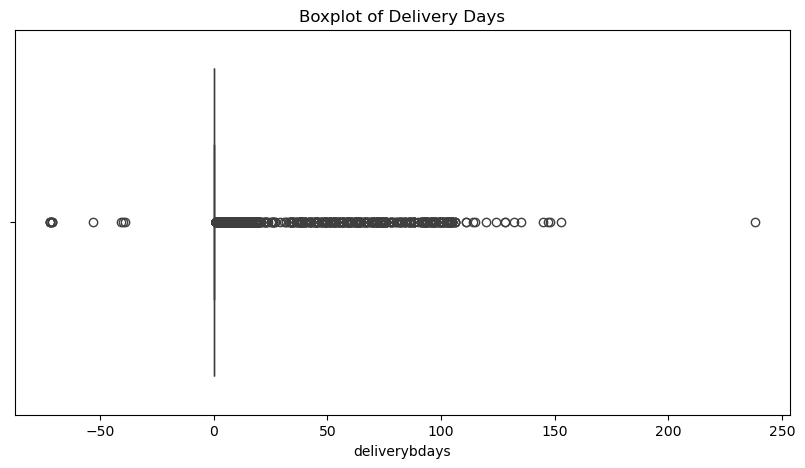

In [ ]:
fsn_id_counts = Customers_Data['fsn_id'].value_counts()
count_of_specific_fsn_id = fsn_id_counts.get("ACCCX3S5AHMF55FV", 0)
count_of_specific_fsn_id #------>Each Type of product have unique fsn_id
Customers_Data['order_id'].nunique() #------>Mtlb ye ho sakta h ke order kiya h 3 products to they have same order_id but different order_idem_id
Customers_Data['order_item_id'].nunique()
order_item_id_counts = Customers_Data['order_item_id'].value_counts()
count_of_specific_order_item = order_item_id_counts.get("1.420831e+15", 0)
count_of_specific_order_item
#Checking for outliers in deliverybdays and deliverycdays
plt.figure(figsize=(10, 5))
sns.boxplot(x='deliverybdays', data=Customers_Data)
plt.title('Boxplot of Delivery Days')
plt.show()


## Clean and Analyze GMV and Units Data

This section cleans and analyzes 'gmv' (Gross Merchandise Value) and 'units' data:

1.  **Replace Missing Values:** Replaces '\\N' and empty strings in 'gmv' and 'units' with `NaN`.
2.  **Convert to Numeric:** Converts 'gmv' and 'units' to numeric, filling `NaN` with 0 and then converting to integers.
3.  **Calculate GMV per Unit:** Computes 'gmv_per_unit' by dividing 'gmv' by 'units'. Replaces infinite values with `NaN` and fills `NaN` with 0, then converts to integers. Recalculates 'gmv_per_unit' again.
4.  **Median GMV per FSN:** Calculates the median 'gmv_per_unit' for each 'fsn_id'.
5.  **GMV per Unit Outlier Check:** Creates a boxplot to visualize outliers in the 'gmv_per_unit' column.

<Axes: xlabel='gmv_per_unit'>

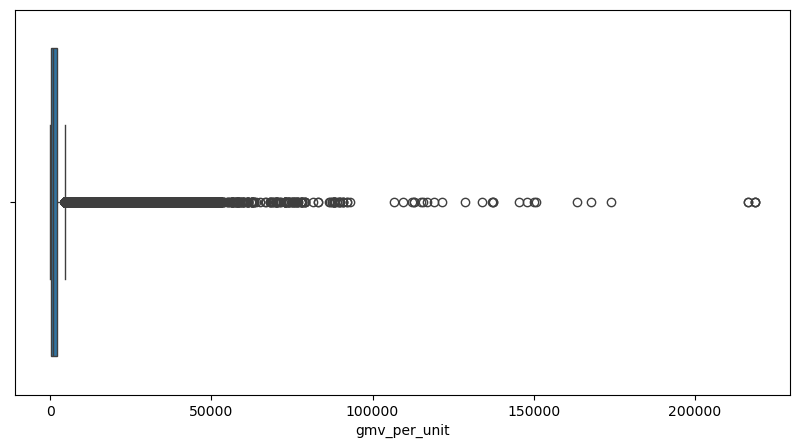

In [13]:
Customers_Data['gmv'] = Customers_Data['gmv'].replace(['\\N', ''], np.nan)
Customers_Data['units'] = Customers_Data['units'].replace(['\\N', ''], np.nan)
Customers_Data['gmv'] = pd.to_numeric(Customers_Data['gmv'], errors='coerce').fillna(0).astype(int)
Customers_Data['units'] = pd.to_numeric(Customers_Data['units'], errors='coerce').fillna(0).astype(int)
missing_gmv_rows = Customers_Data[Customers_Data['gmv'].isna()] #Identify where gmv is missing
Customers_Data['gmv_per_unit'] = Customers_Data['gmv'] / Customers_Data['units'] #Calculating gmv per unit
Customers_Data['gmv_per_unit'] = Customers_Data['gmv_per_unit'].replace([np.inf, -np.inf], np.nan) #Replace inf with NaN
Customers_Data['gmv_per_unit'] = Customers_Data['gmv_per_unit'].fillna(0).astype(int) #Replace NaN with 0
Customers_Data['gmv_per_unit'] = Customers_Data['gmv'] / Customers_Data['units'] #Calculating gmv per unit
gmv_median_per_fsn = Customers_Data.groupby('fsn_id')['gmv_per_unit'].median()  #Find Median of gmv coresponding to each fsn_id
#Checking for outliers in gmv_per_unit
plt.figure(figsize=(10, 5))
sns.boxplot(x='gmv_per_unit', data=Customers_Data)

## Impute Missing GMV

This cell imputes missing 'gmv' values using median 'gmv_per_unit' based on 'fsn_id', then displays the updated DataFrame.

In [14]:
#Imputer funtion
def impute_gmv(row):
    if pd.isna(row['gmv']):
        median_gmv_per_unit = gmv_median_per_fsn.get(row['fsn_id'], np.nan)
        if not pd.isna(median_gmv_per_unit):
            return median_gmv_per_unit * row['units']
    return row['gmv']

Customers_Data['gmv'] = Customers_Data.apply(impute_gmv, axis=1)
Customers_Data['gmv'].isnull().sum()
Customers_Data

,Unnamed: 0,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,sla,cust_id,pincode,product_mrp,product_procurement_sla,gmv_per_unit
0,0,ACCCX3S58G7B5F6P,17-10-2023 15:11,3.419300e+15,3.419300e+15,6400,1,0,0,COD,5,-1.01E+18,-7.79E+18,7190,0,6400.0
1,1,ACCCX3S58G7B5F6P,19-10-2023 10:07,1.420830e+15,1.420830e+15,6900,1,0,0,COD,7,-8.99E+18,7.34E+18,7190,0,6900.0
2,2,ACCCX3S5AHMF55FV,20-10-2023 15:45,2.421910e+15,2.421910e+15,1990,1,0,0,COD,10,-1.04E+18,-7.48E+18,2099,3,1990.0
3,3,ACCCX3S5AHMF55FV,14-10-2023 12:05,4.416590e+15,4.416590e+15,1690,1,0,0,Prepaid,4,-7.60E+18,-5.84E+18,2099,3,1690.0
4,4,ACCCX3S5AHMF55FV,17-10-2023 21:25,4.419530e+15,4.419530e+15,1618,1,0,0,Prepaid,6,2.89E+18,5.35E+17,2099,3,1618.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048570,GAME8HATHWJHWYYE,27-04-2024 00:20,1.581790e+15,1.581790e+15,2499,1,0,0,COD,6,-3110000000000000000.0,6280000000000000000.0,3450,5,2499.0
1048571,1048571,GAME8HATHWJHWYYE,27-04-2024 00:22,2.585130e+15,2.585130e+15,2490,1,3,3,Prepaid,4,-529000000000000000.0,-5130000000000000000.0,3450,5,2490.0
1048572,1048572,GAME8HATHWJHWYYE,27-04-2024 00:22,2.574800e+15,2.574800e+15,2799,1,1,1,Prepaid,3,5680000000000000000.0,-1310000000000000000.0,3450,5,2799.0
1048573,1048573,GAME8HATHWJHWYYE,27-04-2024 00:36,1.582630e+15,1.582630e+15,2775,1,3,4,Prepaid,5,5120000000000000000.0,-336000000000000000.0,3450,5,2775.0


## Payment Type Analysis

This cell analyzes payment types, creates binary COD/Prepaid columns, and calculates 'order_value_per_unit'.

In [15]:
#how many feactures are there in order_payment_type
Customers_Data['order_payment_type'].nunique()
#check if there is some empty cell or not
Customers_Data['order_payment_type'].isnull().sum()
Customers_Data['COD'] = Customers_Data['order_payment_type'].apply(lambda x: 1 if x == 'COD' else 0)
Customers_Data['Prepaid'] = Customers_Data['order_payment_type'].apply(lambda x: 1 if x == 'Prepaid' else 0)
Customers_Data['order_value_per_unit'] = Customers_Data['gmv'] / Customers_Data['units']

## Feature Engineering

This cell creates new features: discount percentage, total delivery time, monthly order frequency, and ensures correct date formatting.

In [16]:
df = Customers_Data
df['discount_percentage'] = ((df['product_mrp'] - df['order_value_per_unit']) / df['product_mrp']) * 100
df['discount_percentage'] = df['discount_percentage'].clip(lower=0)  # To avoid negative discounts if gmv > MRP
df['deliverybdays'] = df['deliverybdays'].replace('\\N', 0).astype(int)
df['deliverycdays'] = df['deliverycdays'].replace('\\N', 0).astype(int)
df['order_fulfillment_time'] = df['deliverybdays'] + df['deliverycdays']
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')  # Ensuring the DatA Format is correct.
df['order_month'] = df['order_date'].dt.to_period('M')
order_freq = df.groupby(['cust_id', 'order_month']).size().reset_index(name='customer_order_frequency_monthly')
df = df.merge(order_freq, on=['cust_id', 'order_month'], how='left')

C:\Users\barna\AppData\Local\Temp\ipykernel_15720\2144152992.py:7: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')  # Ensuring the DatA Format is correct.


## Customer Behavior Features

This cell calculates customer order counts, identifies repeat customers, computes delivery delays, extracts order month, and flags first-time orders.

In [17]:
customer_order_counts = df.groupby('cust_id').size().reset_index(name='order_count')
customer_order_counts['repeat_customer'] = customer_order_counts['order_count'].apply(lambda x: 1 if x > 1 else 0)
df = df.merge(customer_order_counts[['cust_id', 'repeat_customer']], on='cust_id', how='left')
df['delivery_delay_vs_sla'] = df['order_fulfillment_time'] - df['sla']
df['delivery_delay_vs_sla'] = df['delivery_delay_vs_sla'].clip(lower=0)  # No negative delays
df['order_month'] = df['order_date'].dt.month
df['first_order_flag'] = df.sort_values('order_date').groupby('cust_id').cumcount().apply(lambda x: 1 if x == 0 else 0)

## Calculate GMV Percentage

This cell converts 'order_date' and 'gmv' to appropriate types, calculates total daily GMV, and then computes the percentage of each order's GMV relative to the daily total.

In [18]:
# Ensure 'order_date' is datetime if applicable
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Convert 'gmv' to numeric
df['gmv'] = pd.to_numeric(df['gmv'], errors='coerce')

# Group by order_date to get total GMV
total_gmv_per_date = df.groupby('order_date')['gmv'].sum().reset_index()
total_gmv_per_date.columns = ['order_date', 'total_gmv_per_date']
# Merge total GMV back to original DataFrame
df = df.merge(total_gmv_per_date, on='order_date', how='left')
df['gmv_percentage'] = (df['gmv'] / df['total_gmv_per_date']) * 100
df

,Unnamed: 0,fsn_id,order_date,order_id,order_item_id,gmv,units,deliverybdays,deliverycdays,order_payment_type,...,order_value_per_unit,discount_percentage,order_fulfillment_time,order_month,customer_order_frequency_monthly,repeat_customer,delivery_delay_vs_sla,first_order_flag,total_gmv_per_date,gmv_percentage
0,0,ACCCX3S58G7B5F6P,2023-10-17 15:11:00,3.419300e+15,3.419300e+15,6400,1,0,0,COD,...,6400.0,10.987483,0,10,115.0,1.0,0,0,38148,16.776764
1,1,ACCCX3S58G7B5F6P,2023-10-19 10:07:00,1.420830e+15,1.420830e+15,6900,1,0,0,COD,...,6900.0,4.033380,0,10,128.0,1.0,0,0,13516,51.050607
2,2,ACCCX3S5AHMF55FV,2023-10-20 15:45:00,2.421910e+15,2.421910e+15,1990,1,0,0,COD,...,1990.0,5.192949,0,10,132.0,1.0,0,0,3280,60.670732
3,3,ACCCX3S5AHMF55FV,2023-10-14 12:05:00,4.416590e+15,4.416590e+15,1690,1,0,0,Prepaid,...,1690.0,19.485469,0,10,125.0,1.0,0,0,24783,6.819191
4,4,ACCCX3S5AHMF55FV,2023-10-17 21:25:00,4.419530e+15,4.419530e+15,1618,1,0,0,Prepaid,...,1618.0,22.915674,0,10,116.0,1.0,0,0,44431,3.641602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048570,GAME8HATHWJHWYYE,2024-04-27 00:20:00,1.581790e+15,1.581790e+15,2499,1,0,0,COD,...,2499.0,27.565217,0,4,53.0,1.0,0,0,1401599,0.178296
1048571,1048571,GAME8HATHWJHWYYE,2024-04-27 00:22:00,2.585130e+15,2.585130e+15,2490,1,3,3,Prepaid,...,2490.0,27.826087,6,4,7.0,1.0,2,0,1736513,0.143391
1048572,1048572,GAME8HATHWJHWYYE,2024-04-27 00:22:00,2.574800e+15,2.574800e+15,2799,1,1,1,Prepaid,...,2799.0,18.869565,2,4,54.0,1.0,0,0,1736513,0.161185
1048573,1048573,GAME8HATHWJHWYYE,2024-04-27 00:36:00,1.582630e+15,1.582630e+15,2775,1,3,4,Prepaid,...,2775.0,19.565217,7,4,63.0,1.0,2,0,1301943,0.213143


## GMV Categorization

This cell extracts the day of the week from 'order_date', calculates the 80th percentile of 'gmv', categorizes orders as 'Luxury' or 'Normal' based on this percentile, and displays the counts of each category.

In [19]:
df['order_day_of_week'] = df['order_date'].dt.day_name()
# Convert gmv to numeric if it's not already
df['gmv'] = pd.to_numeric(df['gmv'], errors='coerce')
# Calculate 75th percentile of gmv
gmv_80th_percentile = df['gmv'].quantile(0.80)
print(f"80th Percentile of GMV: {gmv_80th_percentile}")
# Add new column 'gmv_category' as 'Luxury' or 'Normal'
df['gmv_category'] = df['gmv'].apply(lambda x: 'Luxury' if x > gmv_80th_percentile else 'Normal')
# Count of Luxury and Normal orders
print(df['gmv_category'].value_counts())

80th Percentile of GMV: 2449.0
gmv_category
Normal    839096
Luxury    209479
Name: count, dtype: int64


## Encode GMV Category and Calculate Elapsed Time

This cell encodes the 'gmv_category' into numerical values (1 for 'Luxury', 0 for 'Normal'), counts unique 'fsn_id' values, converts 'order_date' to datetime format, calculates the elapsed time in minutes since the first order, and displays the first few rows of 'order_date' and 'elapsed_time_minutes'.

In [20]:
# Map 'Luxury' to 1 and 'Normal' to 0
df['gmv_category_encoded'] = df['gmv_category'].map({'Luxury': 1, 'Normal': 0})
df['fsn_id'].nunique()
Customers_Data['order_date'] = pd.to_datetime(Customers_Data['order_date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
# The format is changed to '%Y-%m-%d %H:%M:%S' to match the actual data format.
# errors='coerce' is added to handle any values that still don't match the format and replace them with NaT (Not a Time).
first_order_time = Customers_Data['order_date'].min() #First order
print(first_order_time)
Customers_Data['elapsed_time_minutes'] = (Customers_Data['order_date'] - first_order_time).dt.total_seconds() / 60
Customers_Data['elapsed_time_minutes'] = Customers_Data['elapsed_time_minutes']
print(Customers_Data[['order_date', 'elapsed_time_minutes']].head())

2023-08-30 13:17:00
           order_date  elapsed_time_minutes
0 2023-10-17 15:11:00               69234.0
1 2023-10-19 10:07:00               71810.0
2 2023-10-20 15:45:00               73588.0
3 2023-10-14 12:05:00               64728.0
4 2023-10-17 21:25:00               69608.0


## Analyze GMV by Pincode

This cell calculates the average GMV per pincode, identifies the pincodes with minimum, maximum, and median average GMV, and prints these values.

In [21]:
average_gmv_per_pincode = Customers_Data.groupby('pincode')['gmv'].mean().reset_index()
average_gmv_per_pincode.shape
#finding min_gmv
min_gmv = average_gmv_per_pincode['gmv'].min()
min_gmv_pincode = average_gmv_per_pincode.loc[average_gmv_per_pincode['gmv'] == min_gmv, 'pincode'].values[0]
print('min_gmv = ',min_gmv,' , min_gmv_pincode = ',min_gmv_pincode)
#finding max_gmv
max_gmv = average_gmv_per_pincode['gmv'].max()
max_gmv_pincode = average_gmv_per_pincode.loc[average_gmv_per_pincode['gmv'] == max_gmv, 'pincode'].values[0]
print('max_gmv = ',max_gmv,' , max_gmv_pincode = ',max_gmv_pincode)
#finding median_gmv
median_gmv = average_gmv_per_pincode['gmv'].median()

closest_match = average_gmv_per_pincode.iloc[(average_gmv_per_pincode['gmv'] - median_gmv).abs().argsort()[:1]]

if not closest_match.empty:
    median_gmv_pincode = closest_match['pincode'].values[0]
else:
    median_gmv_pincode = None  # Handle case when no match is found

print('median_gmv =', median_gmv, ', median_gmv_pincode =', median_gmv_pincode)


min_gmv =  99.0  , min_gmv_pincode =  6.91e+17
max_gmv =  47995.0  , max_gmv_pincode =  -8.32E+18
median_gmv = 2200.044297832234 , median_gmv_pincode = 4.65e+18


## Sales Period and Date Feature Engineering

This cell performs date-based feature engineering:

1.  **Sales Mark:** Identifies orders within predefined sales periods and creates a 'sales_mark' column (1 for sales period, 0 otherwise).
2.  **Weekend Flag:** Creates a 'is_weekend' column indicating if the order date is a weekend.
3.  **Drop Payment Type:** Removes the 'order_payment_type' column.
4.  **Special Date Flag:** Creates a 'is_special_date' column to mark if the order date falls within a list of specific dates.
5. **Display Encoded Category:** displays the 'gmv_category_encoded' column.

In [22]:
# Assuming df is your DataFrame and 'order_date' is already converted to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Define sales periods
sales_periods = [
    ('2023-07-18', '2023-07-19'),
    ('2023-08-15', '2023-08-17'),
    ('2023-08-28', '2023-08-30'),
    ('2023-10-15', '2023-10-17'),
    ('2023-11-07', '2023-11-14'),
    ('2023-12-25', '2024-01-03'),
    ('2024-01-20', '2024-01-22'),
    ('2024-02-01', '2024-02-02'),
    ('2024-02-14', '2024-02-15'),
    ('2024-02-20', '2024-02-21'),
    ('2024-03-07', '2024-03-09'),
    ('2024-05-25', '2024-05-27')
]

# Convert sales periods to datetime
sales_periods_dt = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in sales_periods]

# Create a mask for sales periods
mask = np.zeros(len(df), dtype=int)
for start, end in sales_periods_dt:
    mask |= ((df['order_date'] >= start) & (df['order_date'] <= end)).astype(int)

# Apply the mask to create 'sales_mark'
df['sales_mark'] = mask
df['is_weekend'] = df['order_date'].dt.weekday >= 5
df=df.drop(columns=['order_payment_type'])
df.columns
is_specific_dates= (['2023-07-01', '2023-08-03', '2023-09-07', '2023-10-12', '2023-10-11',
 '2024-01-01', '2023-12-25', '2023-12-26', '2024-02-15', '2024-02-14',
 '2024-02-29', '2024-03-17', '2024-03-25', '2024-03-28', '2024-05-08',
 '2024-05-23', '2024-06-19', '2024-06-21', '2024-06-24'])

# Mark True if date is in the specific dates set
df['is_special_date'] = df['order_date'].isin(is_specific_dates)
df['gmv_category_encoded']

C:\Users\barna\AppData\Local\Temp\ipykernel_15720\1348198561.py:39: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_special_date'] = df['order_date'].isin(is_specific_dates)


0          1
1          1
2          0
3          0
4          0
          ..
1048570    1
1048571    1
1048572    1
1048573    1
1048574    1
Name: gmv_category_encoded, Length: 1048575, dtype: int64

## Luxury Item Analysis

This cell filters and analyzes luxury items:

1.  **Filter Luxury Items:** Selects rows where 'gmv_category_encoded' is 1.
2.  **GMV Extraction:** Extracts the 'gmv' column from the filtered luxury items.
3.  **Monthly Analysis:** Groups luxury items by year-month, calculates total GMV and units, computes log growth rate, rolling average of GMV, and the luxury GMV share relative to total monthly GMV.
4.  **Display Results:** Prints the resulting DataFrame with monthly luxury item analysis.

In [23]:
# Filter only luxury items
luxury_items = df[df['gmv_category_encoded'] == 1]

# Display the result
print(luxury_items)
luxury_items = df[df['gmv_category_encoded'] == 1][['gmv']]
print(luxury_items)
# Filter only luxury items and create a copy to avoid warning
luxury_df = df[df['gmv_category_encoded'] == 1].copy()

# Convert 'order_date' to datetime if not already
luxury_df['order_date'] = pd.to_datetime(luxury_df['order_date'])

# Extract year and month
luxury_df['year_month'] = luxury_df['order_date'].dt.to_period('M')

# Group by month and sum GMV & units
gmv_per_month = luxury_df.groupby('year_month', as_index=False).agg({'gmv': 'sum', 'units': 'sum'})

# Compute log growth rate and rolling average
gmv_per_month['gmv_growth_log'] = np.log(gmv_per_month['gmv']).diff()
gmv_per_month['gmv_rolling_avg'] = gmv_per_month['gmv'].rolling(3).mean()

# Compute luxury GMV share
total_gmv_per_month = df.groupby(df['order_date'].dt.to_period('M'))['gmv'].sum()
gmv_per_month['luxury_gmv_share'] = gmv_per_month['gmv'] / total_gmv_per_month.values * 100

# Display the result
print("Luxury Items Analysis")
print(gmv_per_month)

         Unnamed: 0            fsn_id          order_date      order_id  \
0                 0  ACCCX3S58G7B5F6P 2023-10-17 15:11:00  3.419300e+15   
1                 1  ACCCX3S58G7B5F6P 2023-10-19 10:07:00  1.420830e+15   
5                 5  ACCCX3S5JGAJETYR 2023-10-17 12:07:00  3.419190e+15   
6                 6  ACCCX3S5JGAJETYR 2023-10-16 14:59:00  3.418430e+15   
7                 7  ACCCX3S5JGAJETYR 2023-10-15 23:41:00  3.417800e+15   
...             ...               ...                 ...           ...   
1048570     1048570  GAME8HATHWJHWYYE 2024-04-27 00:20:00  1.581790e+15   
1048571     1048571  GAME8HATHWJHWYYE 2024-04-27 00:22:00  2.585130e+15   
1048572     1048572  GAME8HATHWJHWYYE 2024-04-27 00:22:00  2.574800e+15   
1048573     1048573  GAME8HATHWJHWYYE 2024-04-27 00:36:00  1.582630e+15   
1048574     1048574  GAME8HATHWJHWYYE 2024-04-27 01:24:00  4.584430e+15   

         order_item_id   gmv  units  deliverybdays  deliverycdays  sla  ...  \
0         3.419300e+

ValueError: operands could not be broadcast together with shapes (9,) (11,) 

In [24]:
(df['gmv']*df['units']).sum()
#df.to_csv('preprocessed_data.csv', index=False)

2806973682

In [25]:
# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y %H:%M')

df['order_month'] = df['order_date'].dt.to_period('M')
print(Customers_Data[['order_date', 'order_month']].head())

           order_date order_month
0 2023-10-17 15:11:00     2023-10
1 2023-10-19 10:07:00     2023-10
2 2023-10-20 15:45:00     2023-10
3 2023-10-14 12:05:00     2023-10
4 2023-10-17 21:25:00     2023-10


In [26]:
revenue_per_pincode = df.groupby('pincode')['gmv'].sum().reset_index()
print(revenue_per_pincode)
repeat_customers = df['cust_id'].value_counts()[df['cust_id'].value_counts() > 1].count()
total_customers = df['cust_id'].nunique()
repeat_customer_rate = (repeat_customers / total_customers) * 100
print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

                    pincode     gmv
0    -9220000000000000000.0  154408
1    -9210000000000000000.0  248760
2    -9200000000000000000.0  188301
3    -9190000000000000000.0   58176
4    -9180000000000000000.0  421158
...                     ...     ...
4328               9.84E+17  860967
4329             9.8868E+15     175
4330               9.89E+15   11871
4331               9.98E+17    3457
4332               9.99E+17  151791

[4333 rows x 2 columns]
Repeat Customer Rate: 86.99%


## Calculate Delivery Performance

This cell calculates the total delivery time, determines if orders were delivered on time based on SLA, and computes the overall order fulfillment rate.

In [27]:
df['delivery_time'] = df['deliverybdays'] + df['deliverycdays']
df['on_time_delivery'] = df['delivery_time'] <= df['sla']
fulfillment_rate = df['on_time_delivery'].mean() * 100
print(f"Order Fulfillment Rate: {fulfillment_rate:.2f}%")

Order Fulfillment Rate: 92.19%


## Calculate Revenue and Customer Metrics

This cell calculates:

1.  **Revenue:** Computes revenue by subtracting discounts from GMV.
2.  **Total Revenue:** Calculates and prints the sum of all revenue.
3.  **Average Order Value (AOV):** Calculates and prints the average revenue per unique order.
4.  **Customer Lifetime Value (CLV):** Calculates and prints CLV based on AOV, average purchase frequency, and assumed customer lifespan.

In [28]:
df['revenue'] = df['gmv'] - (df['product_mrp'] * df['units'] * df['discount_percentage']/100)
total_revenue = df['revenue'].sum()
print(f"Total Revenue: {total_revenue}")
aov = df['revenue'].sum() / df['order_id'].nunique()
print(f"Average Order Value (AOV): {aov}")
purchase_frequency = df['cust_id'].value_counts().mean()
customer_lifespan = 12  # Assume average retention of 12 months
clv = aov * purchase_frequency * customer_lifespan
print(f"Customer Lifetime Value (CLV): {clv}")

Total Revenue: 695287481.0
Average Order Value (AOV): 9897.18980512733
Customer Lifetime Value (CLV): 11334406.570929121


## Sales Event Impact Analysis

This cell calculates and displays the impact of sales events on GMV by comparing the total GMV during sales periods to the total GMV during normal days.

In [29]:
sales_mark_gmv = df[df['sales_mark'] == 1]['gmv'].sum()
normal_days_gmv = df[df['sales_mark'] == 0]['gmv'].sum()
sales_impact = sales_mark_gmv / normal_days_gmv
print(f"Sales Event Impact: {sales_impact:.2f}x")

Sales Event Impact: 0.30x


## Weekend vs. Weekday GMV Ratio

This cell calculates and prints the ratio of weekend GMV to weekday GMV, indicating the relative sales performance between weekends and weekdays.

In [30]:
weekend_gmv = df[df['is_weekend'] == 1]['gmv'].sum()
weekday_gmv = df[df['is_weekend'] == 0]['gmv'].sum()
weekend_sales_ratio = weekend_gmv / weekday_gmv
print(f"Weekend vs Weekday GMV Ratio: {weekend_sales_ratio:.2f}x")

Weekend vs Weekday GMV Ratio: 0.43x


## Special Date GMV Impact

This cell calculates and displays the impact of special dates on GMV by comparing the total GMV on special dates to the total GMV on normal dates.

In [31]:
special_date_gmv = df[df['is_special_date'] == 1]['gmv'].sum()
normal_date_gmv = df[df['is_special_date'] == 0]['gmv'].sum()
special_date_impact = special_date_gmv / normal_date_gmv
print(f"Special Date GMV Ratio: {special_date_impact:.2f}x")

Special Date GMV Ratio: 0.00x


## Special Date GMV Analysis

This cell analyzes the impact of special dates on GMV:

1.  **Special Date Distribution:** Prints the count of special and normal dates.
2.  **GMV Comparison:** Calculates and prints the ratio of GMV on special dates to normal dates. Handles cases with zero GMV.
3.  **GMV Trend Plot:** Generates a scatter plot to visualize GMV trends on normal and special dates, with special dates marked in red and normal dates in blue.
4.  **Lagged GMV Analysis:** Calculates the GMV lag of 7 days and compares it with the current GMV on special dates, displaying the change percentage.

is_special_date
False    1048549
True          26
Name: count, dtype: int64
Special Date GMV Ratio: 0.00x


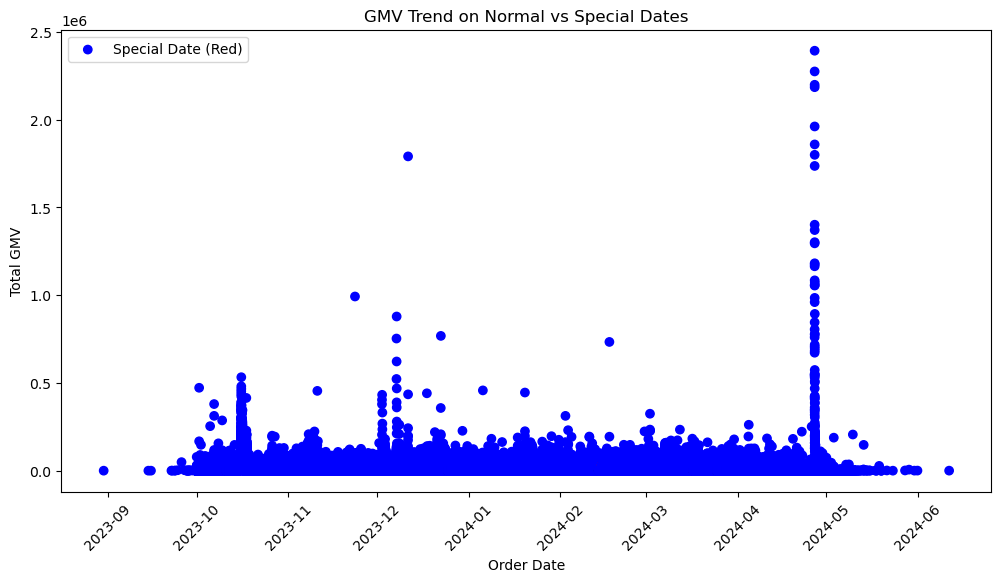

       order_date    gmv  gmv_lag_7   gmv_change
97727  2023-10-11    439      575.0   -23.652174
106658 2023-10-12   2499      338.0   639.349112
16782  2023-10-12    330      499.0   -33.867735
203088 2023-10-12    320     2499.0   -87.194878
430705 2023-12-25    999     1383.0   -27.765727
430405 2023-12-25    139      240.0   -42.083333
443239 2023-12-26   2599    21980.0   -88.175614
458555 2023-12-26    999     3635.0   -72.517194
458480 2023-12-26    900      848.0     6.132075
458049 2023-12-26   1040      848.0    22.641509
340544 2023-12-26    940     5489.0   -82.874841
644903 2024-02-14    329      999.0   -67.067067
698507 2024-02-15    950       99.0   859.595960
674840 2024-02-15   1949      405.0   381.234568
703065 2024-02-15    278      225.0    23.555556
680540 2024-02-15    147      530.0   -72.264151
693347 2024-02-15    355      899.0   -60.511680
673431 2024-02-15    422      199.0   112.060302
713118 2024-02-15    199     1899.0   -89.520800
750362 2024-02-15  2

In [32]:
print(df['is_special_date'].value_counts())  # Check distribution

special_date_gmv = df.loc[df['is_special_date'] == 1, 'gmv'].sum()
normal_date_gmv = df.loc[df['is_special_date'] == 0, 'gmv'].sum()

if normal_date_gmv == 0:
    print("No GMV recorded on normal days, cannot compute ratio.")
elif special_date_gmv == 0:
    print("No GMV recorded on special dates, special event impact is zero.")
else:
    special_date_impact = special_date_gmv / normal_date_gmv
    print(f"Special Date GMV Ratio: {special_date_impact:.2f}x")


import matplotlib.pyplot as plt

# Aggregate GMV by Date
gmv_by_date = df.groupby('order_date')['gmv'].sum().reset_index()

# Mark Special & Normal Days
gmv_by_date['is_special_date'] = gmv_by_date['order_date'].isin(df.loc[df['is_special_date'] == 1, 'order_date'])

# Plot Special vs Normal Day Sales
plt.figure(figsize=(12, 6))
plt.scatter(gmv_by_date['order_date'], gmv_by_date['gmv'], c=gmv_by_date['is_special_date'].map({True: 'red', False: 'blue'}))
plt.xlabel("Order Date")
plt.ylabel("Total GMV")
plt.title("GMV Trend on Normal vs Special Dates")
plt.legend(["Special Date (Red)", "Normal Date (Blue)"])
plt.xticks(rotation=45)
plt.show()


df['order_date'] = pd.to_datetime(df['order_date'])  # Ensure datetime format
df = df.sort_values('order_date')

df['gmv_lag_7'] = df['gmv'].shift(7)  # GMV exactly one week before

# Compare only for special dates
df_special = df[df['is_special_date'] == 1].copy()
df_special['gmv_change'] = ((df_special['gmv'] - df_special['gmv_lag_7']) / df_special['gmv_lag_7']) * 100

print(df_special[['order_date', 'gmv', 'gmv_lag_7', 'gmv_change']])

In [32]:
Holidays

,Occassion,Day
0,Canada Day,"July 1, 2023"
1,Civic Holiday,"August 3, 2023"
2,Labour Day,"September 7, 2023"
3,Thanksgiving,"October 12, 2023"
4,Halloween,"October 31, 2023"
5,Remembrance Day,"November 11, 2023"
6,Christmas Day,"December 25, 2023"
7,Boxing Day,"December 26, 2023"
8,New Year's Day,"January 1, 2024"
9,Islander Day,"February 15, 2024"


## Holiday Order Analysis

This cell creates a DataFrame of Canadian holidays, converts date columns to datetime, creates a 'is_holiday' column in the main DataFrame, and counts the number of orders placed on holidays.

In [33]:
holidays_df = pd.DataFrame({
    'Occasion': ["Canada Day", "Civic Holiday", "Labour Day", "Thanksgiving", "Halloween",
                 "Remembrance Day", "Christmas Day", "Boxing Day", "New Year's Day",
                 "Islander Day", "Louis Riel Day", "Heritage Day", "Family Day",
                 "Valentine's Day", "Leap Day"],
    'Day': ["July 1, 2023", "August 3, 2023", "September 7, 2023", "October 12, 2023", "October 31, 2023",
            "November 11, 2023", "December 25, 2023", "December 26, 2023", "January 1, 2024",
            "February 15, 2024", "February 15, 2024", "February 15, 2024", "February 15, 2024",
            "February 14, 2024", "February 29, 2024"]
})

# Convert 'Day' column in holidays_df to datetime
holidays_df['holiday_date'] = pd.to_datetime(holidays_df['Day'])

# Convert 'order_date' in df to datetime (if not already done)
df['order_date'] = pd.to_datetime(df['order_date'])

# Create 'is_holiday' column (1 if order_date is in holiday list, else 0)
df['is_holiday'] = df['order_date'].isin(holidays_df['holiday_date']).astype(int)

# Verify results
print(df[['order_date', 'is_holiday']].head(10))
num_holiday_orders = df['is_holiday'].sum()
print("Number of orders placed on holidays:", num_holiday_orders)

                order_date  is_holiday
78974  2023-08-30 13:17:00           0
147972 2023-09-14 16:06:00           0
13426  2023-09-15 13:06:00           0
203777 2023-09-22 11:26:00           0
188684 2023-09-22 17:17:00           0
40066  2023-09-23 13:42:00           0
112677 2023-09-23 17:11:00           0
191055 2023-09-24 13:29:00           0
16860  2023-09-25 21:10:00           0
52946  2023-09-25 21:10:00           0
Number of orders placed on holidays: 23


## COD vs. Prepaid GMV Comparison

This cell calculates and prints the total GMV for COD and Prepaid orders, and then computes and prints the ratio of COD GMV to Prepaid GMV.

In [34]:
total_gmv_cod = df[df['COD'] == 1]['gmv'].sum()
print(f"Total GMV for COD orders: {total_gmv_cod}")

total_gmv_Prepaid = df[df['Prepaid'] == 1]['gmv'].sum()
print(f"Total GMV for Prepaid orders: {total_gmv_cod}")
total_gmv_cod/total_gmv_Prepaid

Total GMV for COD orders: 1515424027
Total GMV for Prepaid orders: 1515424027


1.315478240677746

## Merge and Analyze Product Details

This cell merges product category, sub-category, and product name information from `SKU_details` into the main DataFrame (`df`) based on `fsn_id`. It then counts and displays the unique values and value counts for the 'Category' and 'Sub_Category' columns.

In [35]:
product_details = SKU_details
product_details = product_details[['fsn_id', 'product_analytic_category']]
df = df.merge(product_details, on="fsn_id", how="left")
df.rename(columns={"product_analytic_category": "Category"}, inplace=True)
product_details = SKU_details
product_details = product_details[['fsn_id', 'product_analytic_sub_category']]
df = df.merge(product_details, on="fsn_id", how="left")
df.rename(columns={"product_analytic_sub_category": "Sub_Category"}, inplace=True)
product_details = SKU_details  # Reload the original product_details DataFrame
product_details = product_details[['fsn_id', 'product_analytic_vertical']]
df = df.merge(product_details, on="fsn_id", how="left")
df.rename(columns={"product_analytic_vertical": "product"}, inplace=True)
df['Category'].nunique()
df['Sub_Category'].nunique()
df['Category'].value_counts()
df['Sub_Category'].value_counts()


Sub_Category
Speaker                362022
CameraAccessory        149270
GamingAccessory        130782
HomeAudio               82111
AudioMP3Player          73204
TVVideoSmall            73022
Camera                  72577
Game                    68264
GamingConsole           14980
CameraStorage           11302
AudioAccessory           6160
HomeTheatre              2763
AmplifierReceiver        2102
GameMembershipCards        16
Name: count, dtype: int64

## Calculate GMV by Product Categories

This cell calculates and displays the total GMV for each product Category, Sub_Category, and product.

In [36]:
# Group by Category and sum the GMV
category_wise_gmv = df.groupby("Category")["gmv"].sum().reset_index()
# Rename for clarity
category_wise_gmv.rename(columns={"gmv": "total_gmv"}, inplace=True)
# Display the results
print(category_wise_gmv)
# Group by Category and sum the GMV
sub_category_wise_gmv = df.groupby("Sub_Category")["gmv"].sum().reset_index()
# Rename for clarity
sub_category_wise_gmv.rename(columns={"gmv": "total_gmv"}, inplace=True)
# Display the results
print(sub_category_wise_gmv)
# Group by Category and sum the GMV
product_wise_gmv = df.groupby("product")["gmv"].sum().reset_index()
# Rename for clarity
product_wise_gmv.rename(columns={"gmv": "total_gmv"}, inplace=True)
# Display the results
print(product_wise_gmv)

             Category   total_gmv
0              Camera  1285172263
1     CameraAccessory   187381772
2  EntertainmentSmall   800998313
3           GameCDDVD   128488628
4      GamingHardware   265377801
           Sub_Category   total_gmv
0     AmplifierReceiver     3556815
1        AudioAccessory     8960445
2        AudioMP3Player    90265575
3                Camera  1285172263
4       CameraAccessory   176884039
5         CameraStorage    10497733
6                  Game   128485261
7   GameMembershipCards        3367
8       GamingAccessory   105609163
9         GamingConsole   159768638
10            HomeAudio   177733245
11          HomeTheatre    16627153
12              Speaker   410381286
13         TVVideoSmall    93473794
              product  total_gmv
0   AmplifierReceiver    3556815
1      AudioMP3Player   90265575
2          Binoculars   18182580
3             BoomBox    4875529
4          Camcorders   12476882
..                ...        ...
69          Telescope    

## Holiday vs. Non-Holiday Revenue Analysis

This cell analyzes revenue differences between holiday and non-holiday periods:

1.  **Holiday Period Definition:** Defines holiday periods including the day before and after each holiday from the `Holidays` DataFrame.
2.  **Data Split:** Splits the main DataFrame (`df`) into `holiday_sales` and `non_holiday_sales` based on these periods.
3.  **Revenue Distribution Plot:** Generates a histogram comparing the revenue distributions for both periods, including descriptive statistics.
4.  **Statistical Tests:** Performs a t-test to compare the mean revenue between holiday and non-holiday periods and prints summary statistics for each period.

C:\Users\barna\AppData\Local\Temp\ipykernel_15720\859358658.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\barna\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


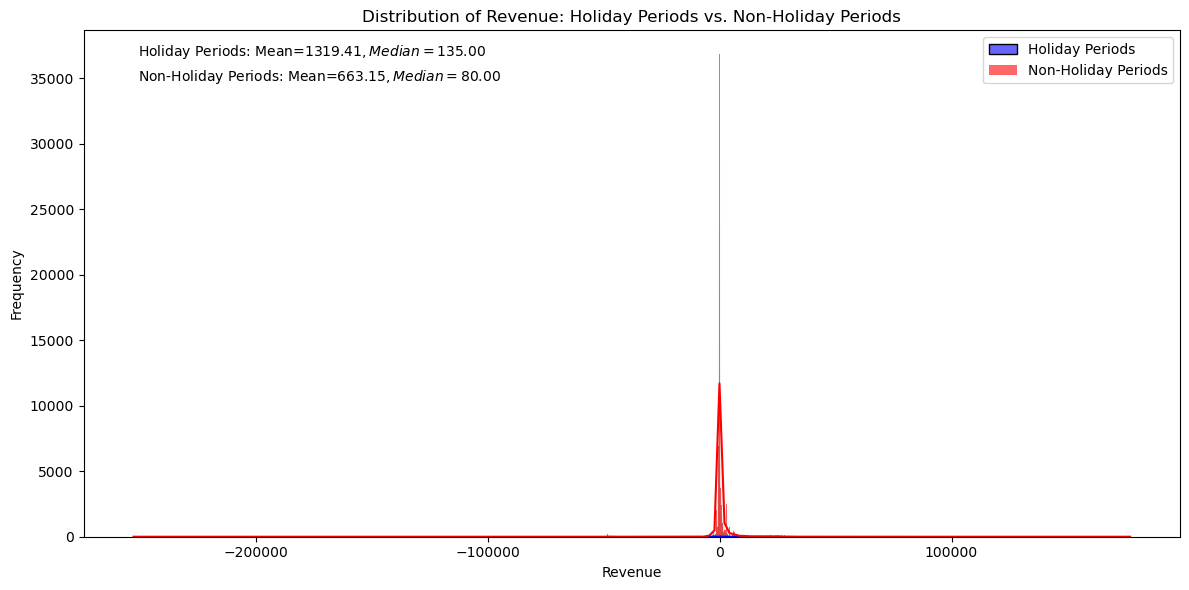

T-test results: t-statistic=nan, p-value=nan

Holiday Periods Statistics:
count       68.000000
mean      1319.411765
std       5091.711981
min      -5992.000000
25%       -447.250000
50%        135.000000
75%        756.750000
max      26950.000000
Name: revenue, dtype: float64

Non-Holiday Periods Statistics:
count    1.048326e+06
mean     6.631504e+02
std      4.432860e+03
min     -2.526100e+05
25%     -3.200000e+02
50%      8.000000e+01
75%      6.990000e+02
max      1.770050e+05
Name: revenue, dtype: float64


In [37]:
from datetime import datetime, timedelta
df_sales = df

# Convert date column to datetime format if it's not already
# df_sales['date'] = pd.to_datetime(df_sales['date'])

# Load the holiday data from the Excel file
holidays_df = Holidays
holidays_df['Day'] = pd.to_datetime(holidays_df['Day'])

# Create a set of holiday dates including day before and day after
holiday_periods = set()
for holiday_date in holidays_df['Day']:
    holiday_periods.add(holiday_date)
    holiday_periods.add(holiday_date - timedelta(days=1))  # Day before
    holiday_periods.add(holiday_date + timedelta(days=1))  # Day after

# Convert to list for easier filtering
holiday_periods = list(holiday_periods)

# Create two separate dataframes for holiday periods and non-holiday periods
holiday_sales = df_sales[df_sales['order_date'].isin(holiday_periods)]
non_holiday_sales = df_sales[~df_sales['order_date'].isin(holiday_periods)]

# Plot the distributions
plt.figure(figsize=(12, 6))

# Plot the distributions using seaborn for better visualization
sns.histplot(holiday_sales['revenue'], kde=True, color='blue', alpha=0.6, label='Holiday Periods')
sns.histplot(non_holiday_sales['revenue'], kde=True, color='red', alpha=0.6, label='Non-Holiday Periods')

plt.title('Distribution of Revenue: Holiday Periods vs. Non-Holiday Periods')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.legend()

# Add some descriptive statistics as text
holiday_stats = f"Holiday Periods: Mean=${holiday_sales['revenue'].mean():.2f}, Median=${holiday_sales['revenue'].median():.2f}"
non_holiday_stats = f"Non-Holiday Periods: Mean=${non_holiday_sales['revenue'].mean():.2f}, Median=${non_holiday_sales['revenue'].median():.2f}"

plt.annotate(holiday_stats, xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)
plt.annotate(non_holiday_stats, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.tight_layout()
plt.show()

# You can also perform statistical tests to compare the distributions
from scipy import stats

# Perform t-test to compare means
t_stat, p_value = stats.ttest_ind(holiday_sales['revenue'], non_holiday_sales['revenue'], equal_var=False)
print(f"T-test results: t-statistic={t_stat:.4f}, p-value={p_value:.4f}")

# If you want to see the summary statistics
print("\nHoliday Periods Statistics:")
print(holiday_sales['revenue'].describe())

print("\nNon-Holiday Periods Statistics:")
print(non_holiday_sales['revenue'].describe())

## Scatter Plots: Features vs. GMV

This cell generates scatter plots to visualize the relationship between various features and GMV. It iterates through specified columns, creating a scatter plot of each against 'gmv'. KeyErrors are handled to skip any missing columns.

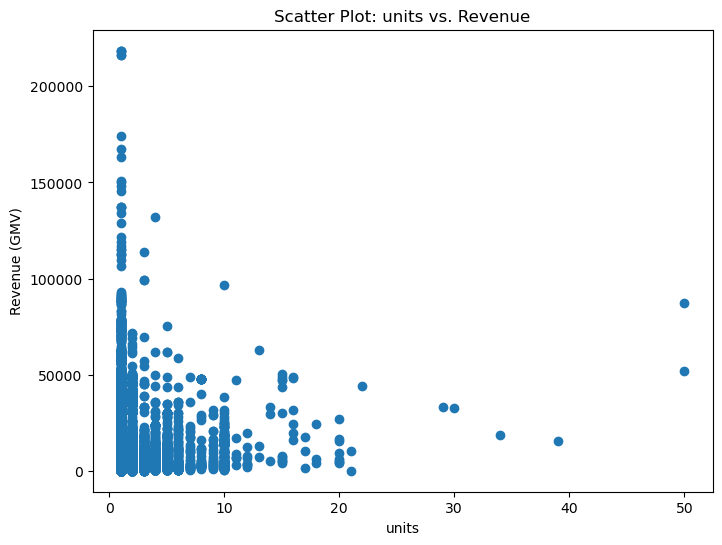

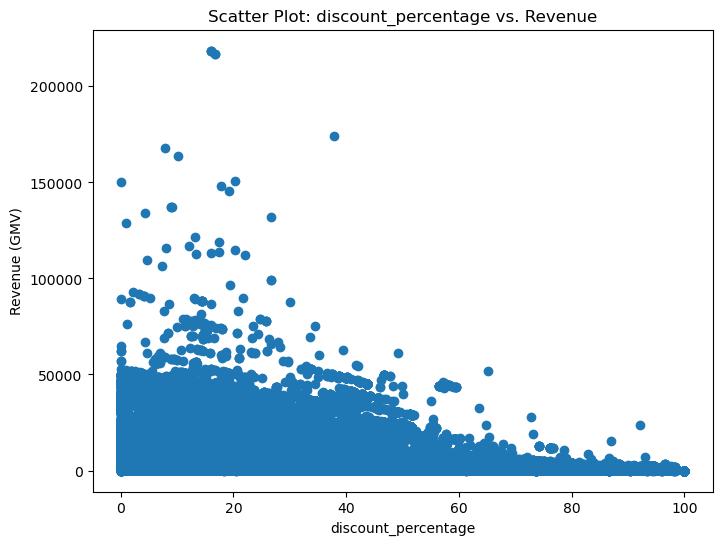

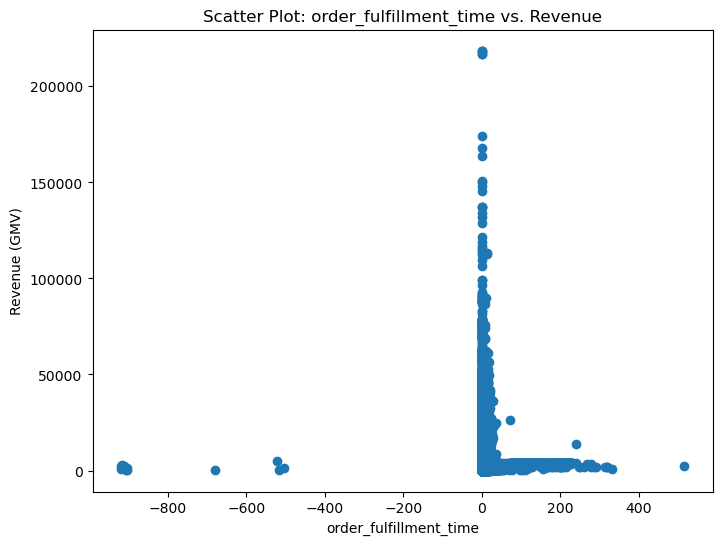

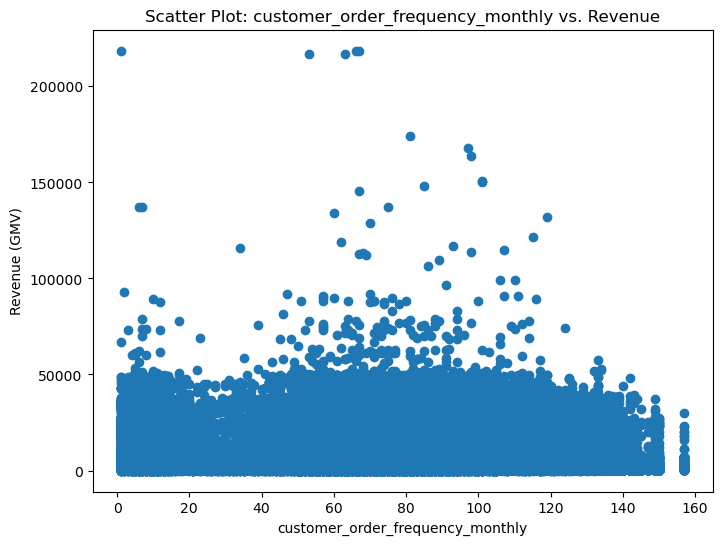

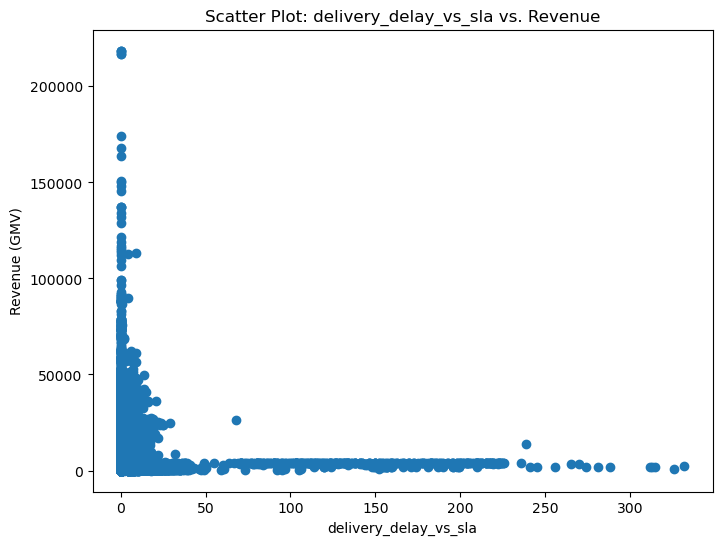

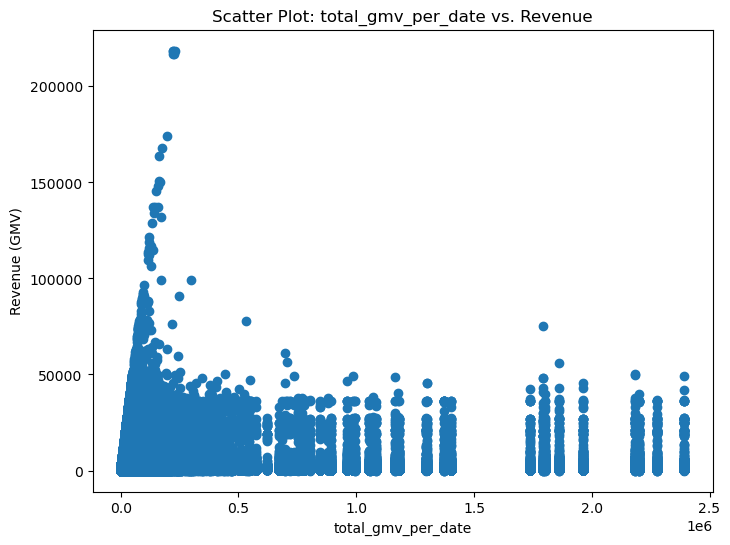

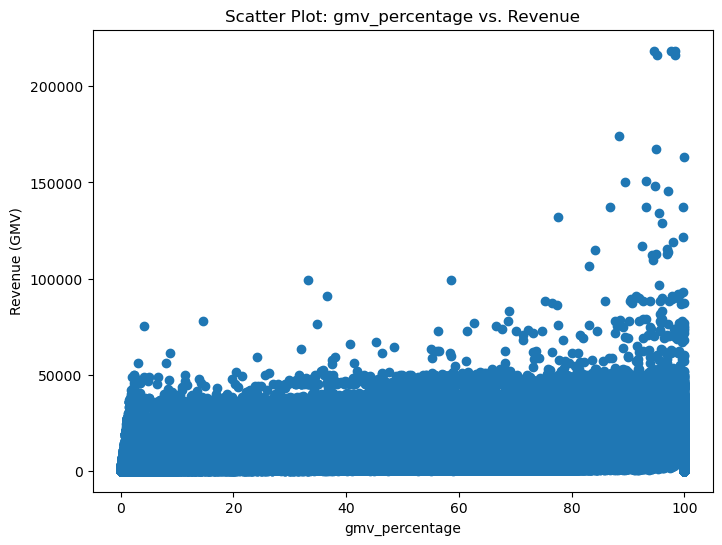

Column ''elapsed_time_minutes'' not found in DataFrame. Skipping...


<Figure size 800x600 with 0 Axes>

In [38]:
df['order_date'] = pd.to_datetime(df['order_date'])

# Generate scatterplots of different columns with revenue
for column in ['units', 'discount_percentage', 'order_fulfillment_time',
               'customer_order_frequency_monthly', 'delivery_delay_vs_sla',
                'total_gmv_per_date', 'gmv_percentage',
               'elapsed_time_minutes']:  # Add more columns as needed
  try:
    plt.figure(figsize=(8, 6))
    plt.scatter(df[column], df['gmv'])
    plt.xlabel(column)
    plt.ylabel('Revenue (GMV)')
    plt.title(f'Scatter Plot: {column} vs. Revenue')
    plt.show()
  except KeyError as e:
    print(f"Column '{e}' not found in DataFrame. Skipping...")
# 'order_month' is causing some problem so removed 

In [41]:
# df = df.drop('gmv_category', axis=1)
df['is_weekend'] = df['is_weekend'].astype(int)
df['is_special_date'] = df['is_special_date'].astype(int)
df = df.rename(columns={'sales_mark': 'is_sale'})

In [42]:
nps_preprocessed_df = pd.read_excel('NPS_stocks.xlsx')
nps_preprocessed_df.head()
preprocessed_df = pd.read_csv('preprocessed_data.csv')
preprocessed_df.head()
media_data = pd.read_excel('media_data.xlsx')

FileNotFoundError: [Errno 2] No such file or directory: 'NPS_stocks.xlsx'

## Key Performance Indicators (KPIs)

This cell calculates and displays various KPIs related to revenue, sales, customer engagement, operational efficiency, seasonal impact, and discount strategies.

In [43]:
preprocessed_df = preprocessed_df.drop('gmv_category', axis=1)

preprocessed_df['is_weekend'] = preprocessed_df['is_weekend'].astype(int)
preprocessed_df['is_special_date'] = preprocessed_df['is_special_date'].astype(int)

preprocessed_df = preprocessed_df.rename(columns={'sales_mark': 'is_sale'})

# Revenue and Sales KPIs
total_gmv = preprocessed_df['gmv'].sum()
total_units = preprocessed_df['units'].sum()
total_orders = preprocessed_df['order_id'].nunique()
average_order_value = total_gmv / total_orders

# Customer and Engagement KPIs
first_orders = preprocessed_df[preprocessed_df['first_order_flag'] == 1].shape[0]
repeat_orders = total_orders - first_orders
first_order_rate = first_orders / total_orders
repeat_order_rate = repeat_orders / total_orders

# Operational and Fulfillment KPIs
delivery_timeliness = (preprocessed_df['deliverybdays'] <= preprocessed_df['sla']).mean() * 100
order_fulfillment_efficiency = (preprocessed_df['deliverybdays'] - preprocessed_df['sla']).mean()

# Seasonal and Promotional Impact
weekend_sales = preprocessed_df[preprocessed_df['is_weekend'] == 1]['gmv'].sum()
special_date_sales = preprocessed_df[preprocessed_df['is_special_date'] == 1]['gmv'].sum()

# Discount and Sales Strategy
if 'is_sale' in preprocessed_df.columns:
    discount_rate = preprocessed_df[preprocessed_df['is_sale'] == 1].shape[0] / total_orders
else:
    discount_rate = "Not Applicable"

# Display KPIs
print(f"Total GMV: {total_gmv}")
print(f"Total Units Sold: {total_units}")
print(f"Average Order Value: {average_order_value}")
print(f"First Order Rate: {first_order_rate}")
print(f"Repeat Order Rate: {repeat_order_rate}")
print(f"Delivery Timeliness: {delivery_timeliness}%")
print(f"Order Fulfillment Efficiency: {order_fulfillment_efficiency} days")
print(f"Weekend Sales: {weekend_sales}")
print(f"Special Date Sales: {special_date_sales}")
print(f"Discount Rate: {discount_rate}")

NameError: name 'preprocessed_df' is not defined

## Monthly KPI Analysis

This cell calculates and displays monthly KPIs:

1.  **Group by Month:** Groups the DataFrame by 'order_month'.
2.  **Calculate KPIs:** Calculates total GMV, units, orders, first orders, weekend sales, and discount rate for each month.
3.  **Compute Additional KPIs:** Calculates average order value, repeat orders, first order rate, and repeat order rate.
4.  **Display Results:** Shows the resulting DataFrame with monthly KPIs.

In [41]:
nps_preprocessed_df['order_month'] = pd.to_datetime(nps_preprocessed_df[['Year', 'Month']].assign(day=1)).dt.to_period('M')
nps_preprocessed_df = nps_preprocessed_df[['order_month', 'NPS']]

# Convert date columns to datetime and create period columns
preprocessed_df['order_date'] = pd.to_datetime(preprocessed_df['order_date'])
preprocessed_df['order_month'] = preprocessed_df['order_date'].dt.to_period('M')
preprocessed_df['order_week'] = preprocessed_df['order_date'].dt.to_period('W')

# Flag repeat customers
customer_order_counts = preprocessed_df.groupby('cust_id')['order_id'].nunique()
repeat_customers = customer_order_counts[customer_order_counts > 1].index
preprocessed_df['is_repeat_customer'] = preprocessed_df['cust_id'].isin(repeat_customers)

# Monthly KPIs aggregation
monthly_kpis = preprocessed_df.groupby('order_month').agg(
    total_gmv=('gmv', 'sum'),
    total_units=('units', 'sum'),
    total_orders=('order_id', 'nunique'),
    first_orders=('first_order_flag', 'sum'),
    weekend_sales=('gmv', lambda x: x[preprocessed_df.loc[x.index, 'is_weekend'] == 1].sum()),
    discount_rate=('is_sale', 'mean'),
    total_unique_customers=('cust_id', 'nunique')
).reset_index()

# Trim the first 2 rows and the last row
monthly_kpis = monthly_kpis.iloc[2:-1].reset_index(drop=True)
monthly_kpis

,order_month,total_gmv,total_units,total_orders,first_orders,weekend_sales,discount_rate,average_order_value,repeat_orders,first_order_rate,repeat_order_rate
0,2023-05,3149,1,1,1,0,0.000000,3149.000000,0,1.000000,0.000000
1,2023-06,4982,6,6,6,713,0.000000,830.333333,0,1.000000,0.000000
2,2023-07,174206832,90938,87534,78421,55584982,0.036828,1990.161903,9113,0.895892,0.104108
3,2023-08,416096,275,155,110,27884,0.044280,2684.490323,45,0.709677,0.290323
4,2023-09,421760671,214008,100804,90347,122120651,0.000000,4183.967610,10457,0.896264,0.103736
5,2023-10,502727831,211939,202216,173621,114712755,0.351026,2486.093242,28595,0.858592,0.141408
6,2023-11,331386937,133345,127268,103052,65656320,0.314386,2603.851219,24216,0.809724,0.190276
7,2023-12,435820199,163021,154008,139345,135338566,0.194200,2829.854287,14663,0.904791,0.095209
8,2024-01,387192999,146899,140510,120751,138721021,0.175755,2755.625927,19759,0.859377,0.140623
9,2024-02,331567025,146990,141135,117651,92652917,0.097311,2349.289864,23484,0.833606,0.166394


In [ ]:
# Additional metrics calculation
monthly_kpis['average_order_value'] = monthly_kpis['total_gmv'] / monthly_kpis['total_orders']
monthly_kpis['repeat_orders'] = monthly_kpis['total_orders'] - monthly_kpis['first_orders']
monthly_kpis['repeat_customers'] = monthly_kpis['total_unique_customers'] - monthly_kpis['first_orders']
monthly_kpis['first_order_rate'] = monthly_kpis['first_orders'] / monthly_kpis['total_orders']
monthly_kpis['repeat_order_rate'] = monthly_kpis['repeat_orders'] / monthly_kpis['total_orders']
monthly_kpis['customer_retention_rate'] = monthly_kpis['repeat_customers'] / monthly_kpis['total_unique_customers'] * 100

# Churn Calculation function (1-month lookback)
def calculate_churn(current_month, months_lookback=1):
    current_month_start = current_month.to_timestamp(how='start')
    lookback_start = (current_month - months_lookback).to_timestamp(how='start')

    customers_in_lookback = preprocessed_df[(preprocessed_df['order_date'] >= lookback_start) &
                               (preprocessed_df['order_date'] < current_month_start)]['cust_id'].unique()
    customers_in_current = preprocessed_df[preprocessed_df['order_month'] == current_month]['cust_id'].unique()

    churned_customers = np.setdiff1d(customers_in_lookback, customers_in_current)
    churn_rate = len(churned_customers) / len(customers_in_lookback) * 100 if len(customers_in_lookback) > 0 else np.nan
    return churn_rate

# Apply churn calculation
X_months = 1
churn_rates = []
months_sorted = sorted(monthly_kpis['order_month'])
for idx, month in enumerate(months_sorted):
    if idx >= X_months:
        churn_rates.append({'order_month': month, 'churn_rate': calculate_churn(month, X_months)})
churn_preprocessed_df = pd.DataFrame(churn_rates)
monthly_kpis = pd.merge(monthly_kpis, churn_preprocessed_df, on='order_month', how='left')

# Merge NPS scores from external data
monthly_kpis = pd.merge(monthly_kpis, nps_preprocessed_df, on='order_month', how='left')

# Warehouse efficiency calculation (ensure columns exist)
if {'deliverybdays', 'deliverycdays'}.issubset(preprocessed_df.columns):
    preprocessed_df['delivery_days'] = preprocessed_df['deliverybdays'] + preprocessed_df['deliverycdays']
    warehouse_metrics = preprocessed_df.groupby('order_month')['delivery_days'].mean().reset_index(name='warehouse_efficiency')
    monthly_kpis = pd.merge(monthly_kpis, warehouse_metrics, on='order_month', how='left')
else:
    monthly_kpis['warehouse_efficiency'] = np.nan

# Risk thresholds definition
risk_thresholds = {
    'high_churn_risk': 15,
    'low_nps_risk': 5,
    'delivery_risk': 10
}

# Calculate risk indicators
monthly_kpis['high_churn_risk'] = monthly_kpis['churn_rate'] > risk_thresholds['high_churn_risk']
monthly_kpis['low_nps_risk'] = monthly_kpis['NPS'] < risk_thresholds['low_nps_risk']
monthly_kpis['delivery_risk'] = monthly_kpis['warehouse_efficiency'] > risk_thresholds['delivery_risk']

risk_columns = ['high_churn_risk', 'low_nps_risk', 'delivery_risk']
monthly_kpis[risk_columns] = monthly_kpis[risk_columns].fillna(False)
monthly_kpis['risk_score'] = monthly_kpis[risk_columns].sum(axis=1)

# Revenue growth metrics calculation
monthly_kpis.sort_values('order_month', inplace=True)
monthly_kpis['gmv_growth_pct'] = monthly_kpis['total_gmv'].pct_change() * 100
monthly_kpis['aov_growth_pct'] = monthly_kpis['average_order_value'].pct_change() * 100

# KPI Summary Function for latest month
def create_latest_summary(kpi_preprocessed_df):
    latest_data = kpi_preprocessed_df.iloc[-1]
    prev_data_available = len(kpi_preprocessed_df) >= 2

    summary_dict = {
        "Month": str(latest_data["order_month"]),
        "Revenue": {
            "Total GMV": f"${latest_data.total_gmv:,.2f}",
            "GMV Growth": f"{latest_data.gmv_growth_pct:.1f}%" if prev_data_available else "N/A",
            "AOV": f"${latest_data.average_order_value:.2f}",
            "AOV Growth": f"{latest_data.aov_growth_pct:.1f}%" if prev_data_available else "N/A"
        },
        "Customer Metrics": {
            "Retention Rate": f"{latest_data.customer_retention_rate:.1f}%",
            "Churn Rate": f"{latest_data.churn_rate:.1f}%" if not np.isnan(latest_data.churn_rate) else "N/A",
            "NPS Score": f"{latest_data.NPS:.1f}" if not np.isnan(latest_data.NPS) else "N/A"
        },
        "Risk Indicators Active": int(latest_data.risk_score)
    }
    return summary_dict

latest_summary_report = create_latest_summary(monthly_kpis)

# Display KPI dashboard summary clearly formatted
print("\n=== ElectroMart E-commerce KPI Dashboard ===\n")
print(f"Latest Month: {latest_summary_report.pop('Month')}\n")
for section, metrics in latest_summary_report.items():
    print(f"{section}:")
    if isinstance(metrics, dict):
        for metric_name, value in metrics.items():
            print(f"  - {metric_name}: {value}")
    else:
        print(f"  - {metrics}")
# Display the trimmed DataFrame
monthly_kpis.head()

In [ ]:
monthly_kpis = pd.read_excel('/content/monthly_kpis_final.xlsx')
monthly_kpis.info()

In [ ]:
# Fill NaN values with the average of the next 3 values

def fill_nan_with_next_3_avg(preprocessed_df):
  for col in preprocessed_df.columns:
    if preprocessed_df[col].isnull().any():
      for i in range(len(preprocessed_df)):
        if pd.isnull(preprocessed_df.loc[i, col]):
          next_3_values = preprocessed_df.loc[i+1:min(i+3, len(preprocessed_df)-1), col].dropna().values
          if len(next_3_values) > 0:
            preprocessed_df.loc[i, col] = np.mean(next_3_values)
  return preprocessed_df


monthly_kpis = fill_nan_with_next_3_avg(monthly_kpis)

In [ ]:
# Convert boolean values to integers (True=1, False=0)
for column in monthly_kpis.columns:
  if monthly_kpis[column].dtype == bool:
    monthly_kpis[column] = monthly_kpis[column].astype(int)

# Assuming 'monthly_kpis' is your DataFrame
if 'order_month' in monthly_kpis.columns:
  monthly_kpis = monthly_kpis.drop('order_month', axis=1)

In [ ]:
monthly_kpis.info()

In [ ]:
# Assuming 'monthly_kpis' is your DataFrame
monthly_kpis.to_excel('/content/drive/MyDrive/GC2025/monthly_kpis_final_changed.xlsx', index=False)
# Fill NaN values with 0 in the specified columns
columns_to_fill = ['Total Investment', 'TV', 'Digital', 'Sponsorship', 'Content Marketing',
                    'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']
media_data[columns_to_fill] = media_data[columns_to_fill].fillna(0)

## Calculating Correlations Between KPIs and Media Spend

This cell calculates and prints the correlations between monthly KPIs and media spending.

1.  **`calculate_correlations` Function:**
    * Iterates through numeric columns in `monthly_kpis`.
    * For each KPI, it calculates the correlation with all numeric columns in `media_data`.
    * Prints the correlation values for each pair.
2.  **`main` Function:**
    * Calls the `calculate_correlations` function to perform the correlation analysis.
3.  **Execution:**
    * Executes the `main` function if the script is run directly.

In [44]:
# without log Transform
# Calculate correlations
def calculate_correlations(monthly_kpis, media_data):
    # Select numeric columns from media_data
    media_numeric = media_data.select_dtypes(include=[np.number])

    # Iterate through each column in monthly_kpis
    for col_kpi in monthly_kpis.columns:
        if monthly_kpis[col_kpi].dtype in [np.float64, np.int64]:  # Ensure column is numeric
            print(f"Correlations for column: {col_kpi}")
            for col_media in media_numeric.columns:
                correlation = monthly_kpis[col_kpi].corr(media_numeric[col_media])
                print(f"  - {col_media}: {correlation}")
            print()  # Newline for readability

# Main function
def main():
    calculate_correlations(monthly_kpis, media_data)

if __name__ == "__main__":
    main()

## Scale Media Spend Data

This cell scales the media spend data by applying a logarithmic transformation to the specified columns. This transformation helps to reduce skewness and bring values to a more manageable range for analysis.

In [45]:
# Multiply values by 10,000,000 and add 1
media_data[columns_to_fill] =np.log( (media_data[columns_to_fill] * 10000000) + 1)
media_data.head()

## Calculate Correlations (Log-Transformed Media Data)

This cell calculates and prints correlations between monthly KPIs and the log-transformed media spend data. It iterates through numeric columns in `monthly_kpis` and calculates their correlations with numeric columns in `media_data`.

In [46]:
# With log Tranform i.e. we are finding the log of the channels and finding the correlations accordingly.
# Calculate correlations
def calculate_correlations(monthly_kpis, media_data):
    # Select numeric columns from media_data
    media_numeric = media_data.select_dtypes(include=[np.number])

    # Iterate through each column in monthly_kpis
    for col_kpi in monthly_kpis.columns:
        if monthly_kpis[col_kpi].dtype in [np.float64, np.int64]:  # Ensure column is numeric
            print(f"Correlations for column: {col_kpi}")
            for col_media in media_numeric.columns:
                correlation = monthly_kpis[col_kpi].corr(media_numeric[col_media])
                print(f"  - {col_media}: {correlation}")
            print()  # Newline for readability

# Main function
def main():
    calculate_correlations(monthly_kpis, media_data)

if __name__ == "__main__":
    main()

In [ ]:
monthly_kpis

In [ ]:
preprocessed_df_ROI_KPI = pd.read_csv('/content/drive/MyDrive/GC2025/preprocessed_df_ROI_KPI')
preprocessed_df_ROI_KPI

In [ ]:
media_data

In [ ]:
revenue = pd.DataFrame({'revenue': monthly_kpis['total_gmv']})
# Display the resulting DataFrame
revenue

In [ ]:
columns_to_drop = ['high_churn_risk', 'low_nps_risk','delivery_risk','risk_score']
for column in columns_to_drop:  # Iterate through each column name
  if column in monthly_kpis.columns:  # Check if the column exists
    monthly_kpis = monthly_kpis.drop(column, axis=1)  # Drop the column

In [ ]:
for column in monthly_kpis.columns:
  if pd.api.types.is_numeric_dtype(monthly_kpis[column]):
    # Perform Min-Max normalization
    monthly_kpis[column] = (monthly_kpis[column] - monthly_kpis[column].min()) / (monthly_kpis[column].max() - monthly_kpis[column].min())
# Print the normalized DataFrame
monthly_kpis.head()

In [ ]:
from scipy.stats import ttest_ind

def find_significant_columns(preprocessed_df):
  """
  Performs pairwise t-tests on all columns of a DataFrame and returns
  a list of column pairs with p-values less than 0.05.

  Args:
    preprocessed_df: The DataFrame to analyze.

  Returns:
    A list of tuples, where each tuple contains two column names
    and their corresponding p-value.
  """
  significant_columns = []
  for col1 in preprocessed_df.columns:
    for col2 in preprocessed_df.columns:
      if col1 != col2:
        try:
          t_statistic, p_value = ttest_ind(preprocessed_df[col1], preprocessed_df[col2])
          if p_value < 0.05:
            significant_columns.append((col1, col2, p_value))
        except Exception as e:
          # Handle potential errors, e.g., non-numeric columns
          print(f"Error comparing {col1} and {col2}: {e}")
  return significant_columns

# Assuming 'monthly_kpis' is your DataFrame
significant_pairs = find_significant_columns(monthly_kpis)

# Print the results
print("Column Pairs with P-value < 0.05:")
for col1, col2, p_value in significant_pairs:
  print(f" - {col1} vs {col2}: p-value = {p_value:.4f}")


In [ ]:
monthly_kpis.head()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Assuming 'monthly_kpis' is your DataFrame
# Create a new DataFrame with only the numerical columns
# Calculate VIF for each KPI
vif_data = pd.DataFrame()
vif_data["feature"] = monthly_kpis.columns
vif_data["VIF"] = [variance_inflation_factor(monthly_kpis.values, i) for i in range(len(monthly_kpis.columns))]

# Filter KPIs with VIF > 5
kpis_with_high_vif = vif_data[vif_data["VIF"] > 5]

print("KPIs with VIF greater than 5:")
kpis_with_high_vif

In [1]:
pip install shap


   ---------------------------------------- 0.0/531.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/531.1 kB ? eta -:--:--
   ---------------------------------------- 531.1/531.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select the 'revenue' column
revenue_data = monthly_kpis[['total_gmv']]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit and transform the revenue data
scaled_revenue = scaler.fit_transform(revenue_data)

# Create a new DataFrame with the scaled revenue
scaled_revenue_preprocessed_df = pd.DataFrame(scaled_revenue, columns=['scaled_revenue'])
scaled_revenue_preprocessed_df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Sample dataset (Replace with your real dataset)
np.random.seed(42)
# data = pd.DataFrame({
#     'feature1': np.random.rand(100),
#     'feature2': np.random.rand(100) * 0.5 + np.random.rand(100) * 0.5,
#     'feature3': np.random.rand(100) * 2,
#     'feature4': np.random.rand(100) * 5 + np.random.rand(100) * 2
# })
# data['target'] = data['feature1'] * 2 + data['feature2'] * 0.5 - data['feature3'] * 0.8 + np.random.rand(100)

# Split data into train and test
X = monthly_kpis
y = scaled_revenue_preprocessed_df
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize data (Ridge works better with standardized features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Ridge Regression model
ridge_model = Ridge(alpha=1.0)  # Regularization strength α=1.0
ridge_model.fit(X_train_scaled, y_train)

# Create SHAP explainer for Ridge
explainer = shap.Explainer(ridge_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Visualize SHAP Feature Importance
shap.summary_plot(shap_values, X_test)

In [ ]:
preprocessed_df_ROI_KPI.info()

In [ ]:
# Assuming 'preprocessed_df_ROI_KPI' is your DataFrame
monthly_kpis.to_excel('/content/drive/MyDrive/GC2025/monthly_kpis_scaled.xlsx', index=False)

In [ ]:
# Assuming 'preprocessed_df_ROI_KPI' is your DataFrame
columns_to_drop = ['Unnamed: 0.1', 'Unnamed: 0']
for column in columns_to_drop:  # Iterate through each column name
  if column in preprocessed_df_ROI_KPI.columns:  # Check if the column exists
    preprocessed_df_ROI_KPI = preprocessed_df_ROI_KPI.drop(column, axis=1)  # Drop the column

In [ ]:
# Assuming 'preprocessed_df_ROI_KPI' is your DataFrame
significant_pairs = find_significant_columns(preprocessed_df_ROI_KPI)

# Print the results
print("Column Pairs with P-value < 0.05:")
for col1, col2, p_value in significant_pairs:
  print(f" - {col1} vs {col2}: p-value = {p_value:.4f}")

In [47]:
df=df_data.copy()
df["gmv"] = pd.to_numeric(df["gmv"], errors="coerce")
df.isnull().sum()
df=df.dropna()
df=df.drop(columns=["Unnamed: 0"])

In [48]:
total_revenue=(df['gmv']*df['units']).sum()
total_revenue_in_crores=total_revenue/1e7
print(f"Total revenue is {total_revenue_in_crores} crores.")

Total revenue is 423.48156284990677 crores.


In [49]:
# calculating daily and monthly revenue
df['revenue']=df['gmv']*df['units']
df["yearmonth"] = pd.to_datetime(df["order_date"]).dt.strftime("%Y-%m")
df["year_month_day"] = pd.to_datetime(df["order_date"]).dt.strftime("%Y-%m-%d")


In [50]:
#  monthly revenue in crores
monthly_revenue = df.groupby('yearmonth')['revenue'].sum()/1e7

In [51]:
monthly_revenue

yearmonth
2023-05     0.000315
2023-06     0.000498
2023-07    18.037639
2023-08     0.042743
2023-09    43.747051
2023-10    52.546963
2023-11    34.586995
2023-12    47.743276
2024-01    40.784913
2024-02    34.485150
2024-03    42.290587
2024-04    35.424087
2024-05    41.874943
2024-06    31.736218
2024-07     0.180185
Name: revenue, dtype: float64

In [52]:
df_media.drop(columns=["Unnamed: 0"],inplace=True)
df_media.drop(index=0, inplace=True)
df_media.reset_index(drop=True, inplace=True)
df_media.columns = df_media.iloc[0]
df_media = df_media.drop(index=0)
df_media.reset_index(drop=True, inplace=True)
df_media=df_media.fillna(0)
df_media["year-month"] = df_media["Year"].astype(str) + "-" + df_media["Month"].astype(str).str.zfill(2)
df_media.set_index("year-month", inplace=True)

df_media

C:\Users\ajsal\AppData\Local\Temp\ipykernel_23604\1887140223.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_media=df_media.fillna(0)


,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other
year-month,,,,,,,,,,,,
2023-07,2023,7,17.061775,0.215330,2.533014,7.414270,0.000933,1.327278,0.547254,5.023697,0.00,0.000000
2023-08,2023,8,5.064306,0.006438,1.278074,1.063332,0.000006,0.129244,0.073684,2.513528,0.00,0.000000
2023-09,2023,9,96.254380,3.879504,1.356528,62.787651,0.610292,16.379990,5.038266,6.202149,0.00,0.000000
2023-10,2023,10,170.156297,6.144711,12.622480,84.672532,3.444075,24.371778,6.973711,31.927011,0.00,0.000000
2023-11,2023,11,51.216220,4.220630,1.275469,14.172116,0.168633,19.561574,6.595767,5.222032,0.00,0.000000
2023-12,2023,12,106.745312,5.397502,3.063360,56.705419,1.067307,22.503756,6.826938,11.181030,0.00,0.000000
2024-01,2024,1,74.196000,4.380000,0.456000,4.200000,0.900000,22.900000,7.370000,4.200000,2.70,27.090000
2024-02,2024,2,48.052000,2.586008,1.912651,11.725555,0.596771,19.892366,6.465019,4.873630,0.00,0.000000
2024-03,2024,3,100.024621,9.300000,2.100000,41.590000,0.370000,18.437818,6.217667,5.193591,0.87,15.945545


In [53]:
monthly_revenue=pd.DataFrame(monthly_revenue)

In [54]:
monthly_revenue['revenue']

yearmonth
2023-05     0.000315
2023-06     0.000498
2023-07    18.037639
2023-08     0.042743
2023-09    43.747051
2023-10    52.546963
2023-11    34.586995
2023-12    47.743276
2024-01    40.784913
2024-02    34.485150
2024-03    42.290587
2024-04    35.424087
2024-05    41.874943
2024-06    31.736218
2024-07     0.180185
Name: revenue, dtype: float64

## Plot Monthly Revenue and Media Investments

This cell generates a plot that visualizes monthly revenue along with the corresponding monthly investments in various media channels. It displays revenue as a solid blue line and each media investment as a dashed line.

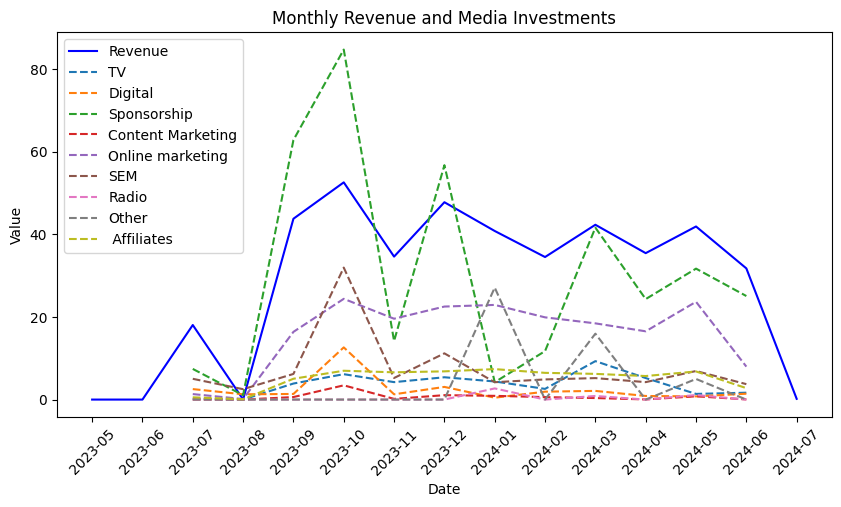

In [55]:
# Plotting monthly revenue and media investments
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue['revenue'], label='Revenue', color='blue')
investment_cols = ["TV", "Digital", "Sponsorship", "Content Marketing",
                    "Online marketing",  "SEM", "Radio", "Other"," Affiliates"]
# Plot investment columns
for col in investment_cols:
    plt.plot(df_media.index, df_media[col], label=col, linestyle='dashed')

plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.title('Monthly Revenue and Media Investments')
plt.xticks(rotation=45)
plt.show()


In [56]:
df_combined=pd.concat([monthly_revenue,df_media],axis=1)


## Fill Missing Values and Recalculate Total Investment

This cell performs two main operations on the `df_combined` DataFrame:

1.  **Fill Missing Values:** Iterates through all columns except "Total Investment" and fills any missing values with the minimum value found in that column.
2.  **Recalculate Total Investment:** Recalculates the "Total Investment" column by summing the values from the specified investment columns ("TV", "Digital", etc.) for each row.

In [57]:
for col in df_combined.columns:
    if col != "Total Investment":
        df_combined[col].fillna(df_combined[col].min(), inplace=True)

# Update 'Total Investment' as sum of specified columns
investment_columns = ["TV", "Digital", "Sponsorship", "Content Marketing",
                      "Online marketing", " Affiliates", "SEM", "Radio", "Other"]

df_combined["Total Investment"] = df_combined[investment_columns].sum(axis=1)

C:\Users\ajsal\AppData\Local\Temp\ipykernel_23604\1180952529.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined[col].fillna(df_combined[col].min(), inplace=True)


## Correlation Heatmap

This cell generates a correlation heatmap to visualize the relationships between different columns in the `df_combined` DataFrame. It displays the correlation coefficients using a color-coded matrix, with numerical annotations for each cell.

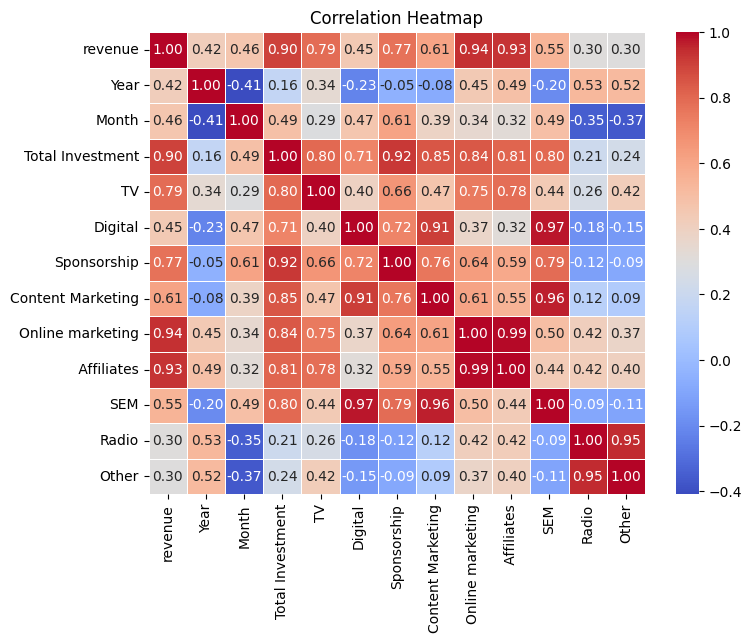

In [58]:
corr_matrix = df_combined.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Log-Transform Investment Data

This cell creates a log-transformed version of the investment data:

1.  **Copy DataFrame:** Creates a copy of `df_combined` to avoid modifying the original data.
2.  **Add Small Constant:** Adds a tiny constant to all values to avoid log(0).
3.  **Log Transformation:** Applies a log transformation (using `np.log1p` for numerical stability) to the specified investment columns.
4.  **Subset DataFrame:** Creates a new DataFrame containing only the log-transformed investment columns and the 'revenue' column.

In [59]:
investment_cols = [
    "Total Investment", "TV", "Digital", "Sponsorship", "Content Marketing",
    "Online marketing", " Affiliates", "SEM", "Radio", "Other"
]
df_log_transformed = df_combined.copy()
df_log_transformed+=.0000001
df_log_transformed[investment_cols] = np.log1p(df_log_transformed[investment_cols])
df_log_transformed = df_log_transformed[investment_cols + ["revenue"]]

## Correlation Heatmap (Log-Transformed Data)

This cell generates a correlation heatmap to visualize the relationships between the log-transformed investment data and revenue. It displays the correlation coefficients using a color-coded matrix with numerical annotations.

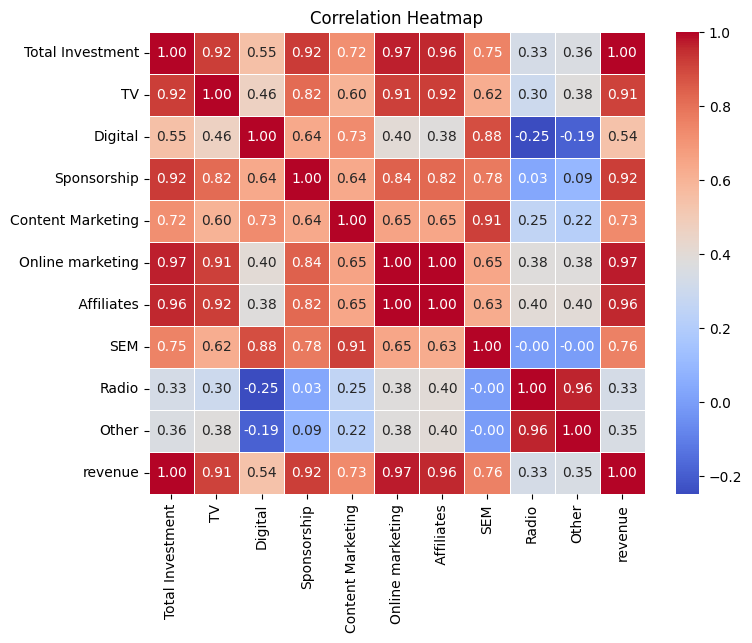

In [60]:
corr_matrix = df_log_transformed.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [61]:
threshold = 0.95
high_corr_pairs = corr_matrix.abs() > threshold
# Mask the diagonal (self-correlation)
np.fill_diagonal(high_corr_pairs.values, False)
# Extract column pairs that meet the threshold
high_corr_pairs = corr_matrix[high_corr_pairs].stack().reset_index()
high_corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
print(high_corr_pairs)

           Feature 1         Feature 2  Correlation
0   Total Investment  Online marketing     0.968355
1   Total Investment        Affiliates     0.957858
2   Total Investment           revenue     0.998393
3   Online marketing  Total Investment     0.968355
4   Online marketing        Affiliates     0.998415
5   Online marketing           revenue     0.971538
6         Affiliates  Total Investment     0.957858
7         Affiliates  Online marketing     0.998415
8         Affiliates           revenue     0.960895
9              Radio             Other     0.962432
10             Other             Radio     0.962432
11           revenue  Total Investment     0.998393
12           revenue  Online marketing     0.971538
13           revenue        Affiliates     0.960895


In [62]:
df_combined['profit']=df_combined['revenue']-df_combined['Total Investment']
cols_to_correlate = list(df_log_transformed.columns) 
df_log_transformed=df_log_transformed.drop(columns=['revenue'])
correlation = df_log_transformed.corrwith(df_combined["profit"])


## Correlation Heatmap with Profit

This cell creates a heatmap visualization of the correlation between various features and profit. It transforms the correlation series into a DataFrame, then uses seaborn to generate a heatmap with annotated correlation values. The heatmap's height is dynamically adjusted based on the number of features, and it uses a 'coolwarm' color scheme with a centered zero point.

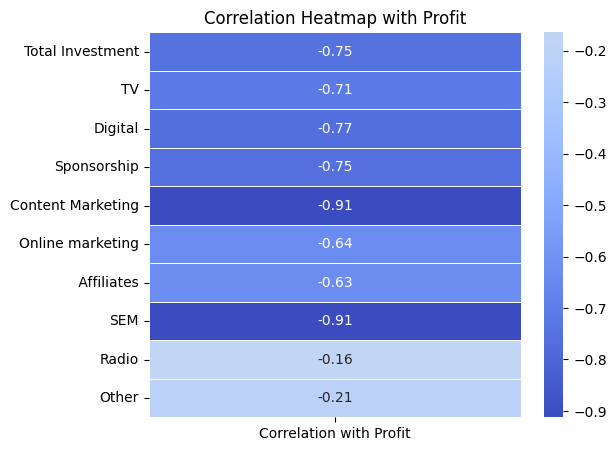

In [63]:
correlation_df = correlation.to_frame(name="Correlation with Profit")

# Plot heatmap
plt.figure(figsize=(6, len(correlation) * 0.5))  # Adjust height dynamically
sns.heatmap(correlation_df, annot=True, cmap="coolwarm", linewidths=0.5, center=0)

plt.title("Correlation Heatmap with Profit")
plt.show()

## Daily Revenue with Holiday Highlights

This cell generates a line plot of daily revenue, highlighting holidays with vertical red dashed lines.

1.  **Plot Daily Revenue:** Creates a line plot of daily revenue over time, marking data points with circles.
2.  **Highlight Holidays:** Iterates through a list of holiday dates and draws vertical red dashed lines at those dates on the plot.
3.  **Labels and Title:** Sets the x-axis label, y-axis label, and plot title.
4.  **Legend and X-Axis Rotation:** Adds a legend and rotates the x-axis labels for better readability.
5.  **Display Plot:** Shows the generated plot.

In [64]:
daily_revenue = df.groupby("year_month_day", as_index=False)["revenue"].sum()
daily_revenue.columns = ["date", "revenue"]
daily_revenue = pd.DataFrame(daily_revenue)

In [65]:
# df_holiday=pd.read_excel('holiday.xlsx')
df_holiday["Day"] = pd.to_datetime(df_holiday["Day"]).dt.strftime("%Y-%m-%d")
df_holiday = df_holiday[["Day"]]
holidays = df_holiday["Day"].tolist()

## Daily Revenue with Holiday Markers

This cell plots the daily revenue and highlights holiday dates:

1.  **Plot Daily Revenue:** Creates a line plot showing daily revenue over time, with markers at each data point.
2.  **Highlight Holidays:** Draws vertical red dashed lines on the plot to mark the occurrence of holidays.
3.  **Labels and Title:** Adds labels to the x and y axes, and sets a title for the plot.
4.  **Legend and Formatting:** Includes a legend to identify the revenue line, and rotates the x-axis labels for better readability.
5.  **Display Plot:** Shows the final plot.

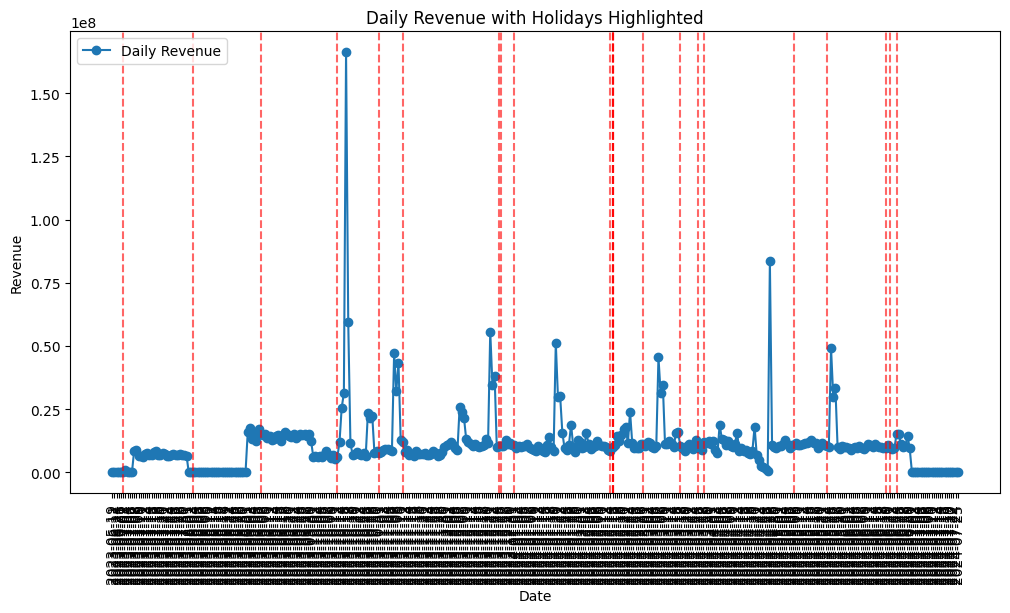

In [66]:
plt.figure(figsize=(12, 6))
plt.plot(daily_revenue["date"], daily_revenue["revenue"], marker="o", label="Daily Revenue")

# Highlight Holidays
for holiday in holidays:
    if holiday in daily_revenue["date"].values:
        plt.axvline(x=holiday, color="r", linestyle="--", alpha=0.6)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Daily Revenue with Holidays Highlighted")
plt.legend()
plt.xticks(rotation=90)
plt.show()


In [ ]:
pre_df=pd.read_csv("/content/preprocessed_data.csv")
print(pre_df['gmv_category_encoded'])

In [ ]:
# Total Spend per customer
total_spend = pre_df.groupby('cust_id')['gmv'].sum()

# Purchase Frequency per customer
purchase_frequency = pre_df.groupby('cust_id')['order_date'].count()

# Preferred Category per customer
##preferred_category = pre_df.groupby('cust_id')['gmv_category_encoded'].agg(lambda x: x.mode()[0])

# Combine into a single dataframe
customer_profiles = pd.DataFrame({
    'Total Spend': total_spend,
    'Purchase Frequency': purchase_frequency,
    ##'Preferred Category': preferred_category
})

In [ ]:
# Distribution of GMV
sns.histplot(pre_df['gmv'], kde=True)
plt.title('Distribution of GMV')
plt.show()

# Spending vs Frequency Scatter Plot
sns.scatterplot(x=customer_profiles['Purchase Frequency'], y=customer_profiles['Total Spend'])
plt.title('Spending vs Purchase Frequency')
plt.show()

# Popular Categories Bar Chart
category_counts = pre_df['gmv_category_encoded'].value_counts()
category_counts.plot(kind='bar')
plt.title('Most Popular Product Categories')
plt.show()

In [ ]:
# Calculate the 75th percentile
percentile_75 = pre_df['gmv'].quantile(0.75)

# Create 'spender_type' column
pre_df['spender_type'] = np.where(pre_df['gmv'] > percentile_75, 'High Spender', 'Low Spender')

# Count spender types
spender_counts = pre_df['spender_type'].value_counts()



In [ ]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie Chart
spender_counts = pre_df['spender_type'].value_counts()
ax1.pie(spender_counts, labels=spender_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette('pastel'))
ax1.set_title('Proportion of High vs Low Spenders')

# Histogram with stacked bars
sns.histplot(data=pre_df, x='gmv', hue='spender_type',
             bins=30, palette='pastel', ax=ax2)
ax2.set_title('Distribution of GMV by Spender Type')
ax2.set_xlabel('GMV Value')
ax2.set_ylabel('Count')
ax2.legend(title='Spender Type')

plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Count orders per customer
order_counts = pre_df['cust_id'].value_counts()

# Step 2: Categorize buyers
buyer_types = pd.cut(order_counts,
                     bins=[0, 1, float('inf')],
                     labels=['One-time Buyer', 'Frequent Buyer'])

# Step 3: Count the number of each buyer type
buyer_type_counts = buyer_types.value_counts()

# Step 4: Plot bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=buyer_type_counts.index, y=buyer_type_counts.values, palette="pastel")
plt.title('Distribution of One-time vs Frequent Buyers')
plt.xlabel('Buyer Type')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. Create Customer Profiles (without category data)
customer_profiles = pre_df.groupby('cust_id').agg(
    Total_Spend=('gmv', 'sum'),
    Purchase_Frequency=('order_date', 'count'),
    Total_Discount=('discount_percentage', 'sum'),
    Last_Purchase=('order_date', 'max')
).reset_index()

# 2. Calculate Metrics
customer_profiles['GMV_per_Order'] = customer_profiles['Total_Spend'] / customer_profiles['Purchase_Frequency']
customer_profiles['Discount_Pct'] = customer_profiles['Total_Discount'] / customer_profiles['Total_Spend']

# 3. Define Segments (adjusted definitions)
# Calculate thresholds
top_20_pct_freq = customer_profiles['Purchase_Frequency'].quantile(0.8)
recent_threshold = datetime.now() - timedelta(days=30)

# Convert 'Last_Purchase' to datetime objects if it's currently strings
customer_profiles['Last_Purchase'] = pd.to_datetime(customer_profiles['Last_Purchase'])

# Initialize segments
customer_profiles['Segment'] = 'Other'

# Loyal Customers (top 20% frequency only)
customer_profiles.loc[
    customer_profiles['Purchase_Frequency'] >= top_20_pct_freq,
    'Segment'] = 'Loyal Customers'

# Discount Seekers (high discount % + low GMV/order)
customer_profiles.loc[
    (customer_profiles['Discount_Pct'] > 30) &  # 30% threshold
    (customer_profiles['GMV_per_Order'] < customer_profiles['GMV_per_Order'].median()),
    'Segment'] = 'Discount Seekers'

# One-time Buyers
customer_profiles.loc[
    customer_profiles['Purchase_Frequency'] == 1,
    'Segment'] = 'One-time Buyers'

# New Buyers
customer_profiles.loc[
    customer_profiles['Last_Purchase'] >= recent_threshold,
    'Segment'] = 'New Buyers'


# 4. Visualize Segment Distribution
plt.figure(figsize=(12, 6))

# Pie Chart
plt.subplot(1, 2, 1)
segment_counts = customer_profiles['Segment'].value_counts()
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Customer Segment Distribution')

# Bar Plot
plt.subplot(1, 2, 2)
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="pastel")
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Segment Characteristics Analysis
plt.figure(figsize=(15, 5))
metrics = ['Purchase_Frequency', 'GMV_per_Order', 'Discount_Pct']

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Segment', y=metric, data=customer_profiles, hue='Segment', legend=False, palette="pastel")  # Add hue='Segment' and legend=False
    plt.title(f'{metric} Distribution')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:

from scipy import stats
from datetime import datetime, timedelta

# 1. Add Time Period Flags
# Convert 'order_date' to datetime objects before any operations
pre_df['order_date'] = pd.to_datetime(pre_df['order_date'])

# Create a new column to categorize periods: Pre-Sale, During-Sale, Post-Sale
pre_df['period'] = np.where(
    (pre_df['sales_mark'] == 1), 'During-Sale',  # Orders with sales_mark = 1 are during the sale
    np.where(
        (pre_df['sales_mark'] == 0) & (pre_df['order_date'] < (pre_df['order_date'].max() - timedelta(days=7))), 'Pre-Sale', # Orders before the sale period
        'Post-Sale'  # Orders after the sale period (sales_mark = 0 but not within the pre-sale timeframe)
    )
)


# 2. Calculate Aggregated Metrics
period_gmv = pre_df.groupby('period').agg(
    avg_gmv=('gmv', 'mean'),
    total_orders=('gmv', 'count')
).reset_index()

# 3. Visualize GMV Trends by Period
plt.figure(figsize=(15, 6))

# Boxplot Comparison
sns.boxplot(
    x='period',
    y='gmv',
    data=pre_df,
    order=['Pre-Sale', 'During-Sale', 'Post-Sale'],
    palette='pastel'
)
plt.title('GMV Distribution by Period')
plt.xlabel('Promotion Period')
plt.ylabel('GMV')
plt.show()

# 4. Statistical Testing
# Separate GMV values by period
pre_sale_gmv = pre_df[pre_df['period'] == 'Pre-Sale']['gmv']
during_sale_gmv = pre_df[pre_df['period'] == 'During-Sale']['gmv']
post_sale_gmv = pre_df[pre_df['period'] == 'Post-Sale']['gmv']

# ANOVA Test to check if GMV differs significantly across periods
f_stat, p_value = stats.f_oneway(pre_sale_gmv, during_sale_gmv, post_sale_gmv)
print(f"ANOVA Results: F-stat={f_stat:.2f}, p-value={p_value:.4f}")

# Pairwise T-Tests for detailed comparisons
print("\nPairwise Comparisons:")
for pair in [('Pre-Sale', 'During-Sale'), ('During-Sale', 'Post-Sale'), ('Pre-Sale', 'Post-Sale')]:
    t_stat, p_val = stats.ttest_ind(
        pre_df[pre_df['period'] == pair[0]]['gmv'],
        pre_df[pre_df['period'] == pair[1]]['gmv']
    )
    print(f"{pair[0]} vs {pair[1]}: t={t_stat:.2f}, p={p_val:.4f}")

# 5. Analyze Discount Impact (if discount% column exists)
if 'discount%' in pre_df.columns:
    # Group by discount levels and calculate post-sale engagement rate
    pre_df['discount_group'] = pd.cut(
        pre_df['discount%'],
        bins=[0, 10, 20, 30, 100],
        labels=['0-10%', '11-20%', '21-30%', '>30%']
    )

    discount_impact = pre_df.groupby('discount_group').agg(
        avg_gmv=('gmv', 'mean'),
        post_sale_rate=('sales', lambda x: (x.shift(-1) == 0).mean())
    ).reset_index()

    # Visualize Discount Impact on Post-Sale Engagement
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x='discount_group',
        y='post_sale_rate',
        data=discount_impact,
        palette='pastel'
    )
    plt.title('Post-Sale Engagement by Discount Level')
    plt.xlabel('Discount Percentage Group')
    plt.ylabel('Post-Sale Engagement Rate')
    plt.ylim(0, 1)
    plt.show()


In [ ]:
from scipy import stats
from datetime import timedelta

# Assuming pre_df is your DataFrame with columns: order_date, gmv, sales_mark, discount%

# 1. Prepare the data
pre_df['order_date'] = pd.to_datetime(pre_df['order_date'])
pre_df = pre_df.sort_values('order_date')

# 2. Identify sale periods and classify orders
sale_dates = pre_df[pre_df['sales_mark'] == 1]['order_date'].unique()
pre_sale_windows = [d - pd.Timedelta(days=7) for d in sale_dates]
post_sale_windows = [d + pd.Timedelta(days=7) for d in sale_dates]

conditions = [
    pre_df['sales_mark'] == 1,
    pre_df['order_date'].isin(pre_sale_windows),
    pre_df['order_date'].isin(post_sale_windows)
]
choices = ['During-Sale', 'Pre-Sale', 'Post-Sale']
pre_df['period'] = np.select(conditions, choices, default='Non-Sale')

# 3. Calculate aggregated metrics
period_gmv = pre_df.groupby('period').agg(
    avg_gmv=('gmv', 'mean'),
    total_orders=('gmv', 'count')
).reset_index()

# 4. Visualize GMV trends by period
plt.figure(figsize=(15, 6))
sns.boxplot(
    x='period',
    y='gmv',
    data=pre_df,
    order=['Non-Sale', 'Pre-Sale', 'During-Sale', 'Post-Sale'],
    palette='pastel'
)
plt.title('GMV Distribution by Period')
plt.xlabel('Promotion Period')
plt.ylabel('GMV')
plt.show()

# 5. Statistical testing
periods = ['Non-Sale', 'Pre-Sale', 'During-Sale', 'Post-Sale']
gmv_by_period = [pre_df[pre_df['period'] == period]['gmv'] for period in periods]

f_stat, p_value = stats.f_oneway(*gmv_by_period)
print(f"ANOVA Results: F-stat={f_stat:.2f}, p-value={p_value:.4f}")

print("\nPairwise Comparisons:")
for i in range(len(periods)):
    for j in range(i+1, len(periods)):
        t_stat, p_val = stats.ttest_ind(gmv_by_period[i], gmv_by_period[j])
        print(f"{periods[i]} vs {periods[j]}: t={t_stat:.2f}, p={p_val:.4f}")

# 6. Analyze discount impact (if discount% column exists)
if 'discount%' in pre_df.columns:
    pre_df['discount_group'] = pd.cut(
        pre_df['discount%'],
        bins=[0, 10, 20, 30, 100],
        labels=['0-10%', '11-20%', '21-30%', '>30%']
    )

    discount_impact = pre_df.groupby(['discount_group', 'period']).agg(
        avg_gmv=('gmv', 'mean'),
        order_count=('gmv', 'count')
    ).reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(
        x='discount_group',
        y='avg_gmv',
        hue='period',
        data=discount_impact,
        palette='viridis'
    )
    plt.title('Average GMV by Discount Level and Period')
    plt.xlabel('Discount Percentage Group')
    plt.ylabel('Average GMV')
    plt.legend(title='Period')
    plt.show()

# 7. Visualize sale period classification
plt.figure(figsize=(15, 6))
sns.scatterplot(x='order_date', y='period', data=pre_df, hue='period', palette='deep')
plt.title('Sale Period Classification Over Time')
plt.xlabel('Order Date')
plt.ylabel('Period')
plt.show()

# 8. Print summary statistics
print("\nSummary Statistics:")
print(period_gmv)

# 9. Calculate and print lift metrics
non_sale_gmv = period_gmv[period_gmv['period'] == 'Non-Sale']['avg_gmv'].values[0]
for period in ['Pre-Sale', 'During-Sale', 'Post-Sale']:
    period_gmv_val = period_gmv[period_gmv['period'] == period]['avg_gmv'].values[0]
    lift = (period_gmv_val - non_sale_gmv) / non_sale_gmv * 100
    print(f"{period} GMV Lift: {lift:.2f}%")

In [ ]:

from statsmodels.tsa.stattools import ccf, grangercausalitytests
from statsmodels.api import OLS, add_constant

# Create DataFrame based on the provided data
data = pd.DataFrame({
    "gmv_per_month": [174206832, 416096, 421760671, 502727831, 331386937, 435820199, 387192999, 331567025, 404003023, 339703548, 409453151, 305913306],
    "Year": [2023]*6 + [2024]*6,
    "Month": [7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6],
    "Total_Investment": [170617754.43, 50643060.89, 962543798.65, 1701562973.68, 512162204.16, 1067453117.16, 741960000.00, 480520000.00, 1000246214.29, 568482413.79, 780570000.00, 428342164.25]
})

# Convert Year and Month to a Date format
data["Date"] = pd.to_datetime(data[["Year", "Month"]].assign(day=1))
data = data.sort_values("Date").reset_index(drop=True)

# Visualizing trends with updated column name
plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["gmv_per_month"], label="GMV per Month", color='blue')
plt.plot(data["Date"], data["Total_Investment"], label="Total Media Spend", color='red')
plt.legend()
plt.title("GMV per Month vs Media Spend")
plt.show()

# Lagged Correlation Analysis (updated column name)
max_lag = 3
correlations = {}
for lag in range(max_lag + 1):
    correlations[f"Lag_{lag}"] = data["gmv_per_month"].corr(data["Total_Investment"].shift(lag))

print("Lagged Correlations:")
print(pd.DataFrame.from_dict(correlations, orient='index', columns=["Correlation"]))

# Cross-Correlation Function (updated column name)
lags = np.arange(0, 4)
cc_values = [ccf(data["Total_Investment"].dropna(), data["gmv_per_month"].dropna(), adjusted=False)[lag] for lag in lags]
plt.bar(lags, cc_values)
plt.title("Cross-Correlation Function (CCF)")
plt.xlabel("Lags (Months)")
plt.ylabel("Correlation")
plt.show()


In [ ]:
# Define retention criteria
X_months = 6  # Define churn threshold
today = pre_df["order_date"].max()
customer_last_purchase = pre_df.groupby("cust_id")["order_date"].max()

# Determine churned and retained customers
# Handle missing values in customer_last_purchase using .get() with a default value
pre_df["Churned"] = pre_df["cust_id"].map(lambda x: (today - customer_last_purchase.get(x, today)).days > (X_months * 30))



# Calculate Repeat Purchase Rate
repeat_customers = pre_df.groupby("cust_id")["cust_id"].count() > 1
repeat_purchase_rate = (repeat_customers.sum() / pre_df["cust_id"].nunique()) * 100
print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")

## Clean Weather Data

This cell cleans the weather data by removing flag columns and specific columns related to maximum gust information from both 2023 and 2024 weather datasets.

In [67]:
Weather_Data_2024 = Weather_Data_2024[[col for col in Weather_Data_2024.columns if not col.endswith('Flag')]]
Weather_Data_2023 = Weather_Data_2023[[col for col in Weather_Data_2023.columns if not col.endswith('Flag')]]
cols_to_remove = ['Dir of Max Gust (10s deg)', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']
Weather_Data_2024 = Weather_Data_2024.drop(columns=[col for col in Weather_Data_2024.columns if col in cols_to_remove])
cols_to_remove = ['Dir of Max Gust (10s deg)', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']
Weather_Data_2023 = Weather_Data_2023.drop(columns=[col for col in Weather_Data_2023.columns if col in cols_to_remove])

## Combine and Visualize Weather Data

This cell combines weather data from 2023 and 2024, and then visualizes the maximum and minimum temperatures over time.

1.  **Concatenate Data:** Combines the `Weather_Data_2023` and `Weather_Data_2024` DataFrames into a single DataFrame called `combined_weather_data_before_imputation`.
2.  **Display Head:** Displays the first few rows of the combined DataFrame.
3.  **Plot Temperatures:** Creates a line plot showing the maximum and minimum temperatures over time, with markers at each data point.
4.  **Labels and Title:** Adds labels to the x and y axes, and sets a title for the plot.
5.  **Legend, Grid, and Formatting:** Includes a legend, adds a grid for better readability, rotates x-axis labels, and adjusts the layout.
6.  **Display Plot:** Shows the final plot.

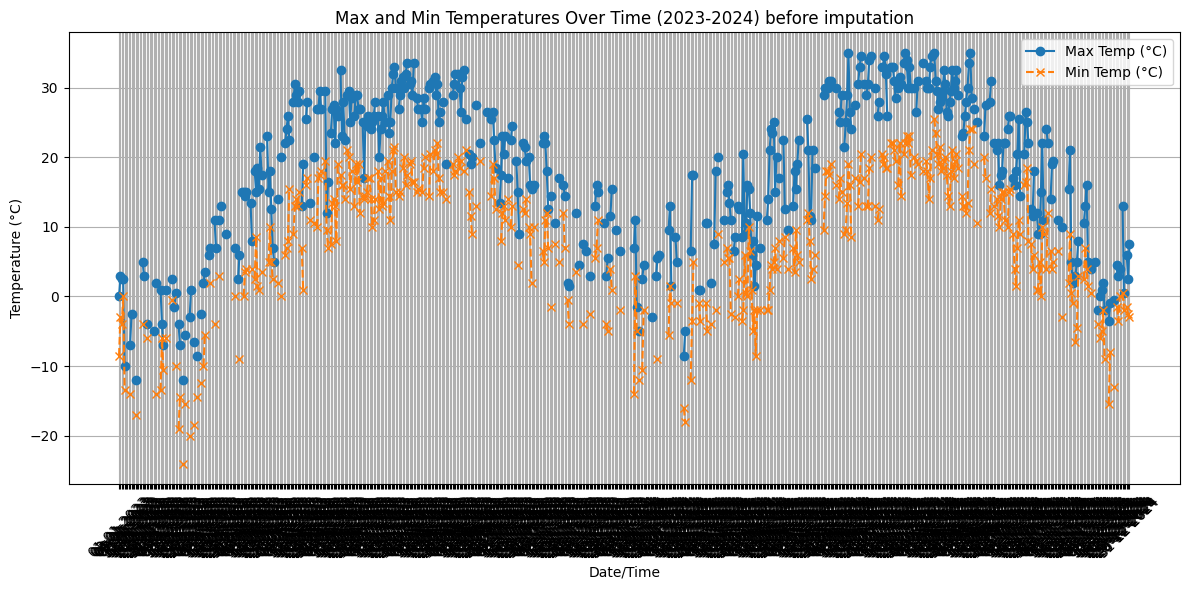

In [68]:
# Concatenating the two DataFrames
combined_weather_data_before_imputation = pd.concat([Weather_Data_2023, Weather_Data_2024], ignore_index=True)
# Displaying the first few rows of the combined dataset
combined_weather_data_before_imputation.head
plt.figure(figsize=(12, 6))
plt.plot(combined_weather_data_before_imputation['Date/Time'], combined_weather_data_before_imputation['Max Temp (°C)'], label='Max Temp (°C)', marker='o', linestyle='-')
plt.plot(combined_weather_data_before_imputation['Date/Time'], combined_weather_data_before_imputation['Min Temp (°C)'], label='Min Temp (°C)', marker='x', linestyle='--')
plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.title('Max and Min Temperatures Over Time (2023-2024) before imputation')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Impute Missing Values with Rolling Average

This cell defines a function to fill missing values in a specified column of a DataFrame using a rolling average of the surrounding values.

1.  **`fill_missing_with_average` Function:**
    * Takes a DataFrame and a column name as input.
    * Iterates through the values in the specified column.
    * If a value is missing (NaN), it calculates the average of the 3 preceding and 3 following non-missing values.
    * Replaces the missing value with the calculated average.
    * Updates the column in the DataFrame with the imputed values.

In [69]:
def fill_missing_with_average(data, column):
    # Strip any leading/trailing spaces or special characters in column names
    data.columns = data.columns.str.strip()
    values = data[column].to_numpy()
    for i in range(len(values)):
        if pd.isna(values[i]):
            # Get previous 3 and next 3 values
            prev_values = values[max(0, i-3):i]
            next_values = values[i+1:min(len(values), i+4)]

            # Replace NaN with 0 in the slices
            prev_values = np.nan_to_num(prev_values, nan=0)
            next_values = np.nan_to_num(next_values, nan=0)

            # Calculate the average of the previous 3 and next 3 values
            avg = (np.sum(prev_values) + np.sum(next_values)) / (len(prev_values) + len(next_values))
            values[i] = avg
    data[column] = values

In [70]:
columns_to_fill = ['Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)','Heat Deg Days (°C)','Cool Deg Days (°C)','Total Rain (mm)','Total Snow (cm)','Total Precip (mm)','Snow on Grnd (cm)']
for column in columns_to_fill:
    fill_missing_with_average(Weather_Data_2023, column)
    columns_to_fill = ['Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)','Heat Deg Days (°C)','Cool Deg Days (°C)','Total Rain (mm)','Total Snow (cm)','Total Precip (mm)','Snow on Grnd (cm)']
for column in columns_to_fill:
    fill_missing_with_average(Weather_Data_2024, column)

## 2023 Temperature Data After Imputation

This cell generates a plot showing the maximum and minimum temperatures over time for the year 2023, after missing values have been imputed.

1.  **Plot Temperatures:** Creates a line plot of maximum and minimum temperatures against time, using markers.
2.  **Labels and Title:** Adds axis labels and a title to the plot.
3.  **Legend, Grid, and Formatting:** Includes a legend, displays a grid, rotates x-axis labels, and adjusts the layout.
4.  **Display Plot:** Shows the resulting plot.

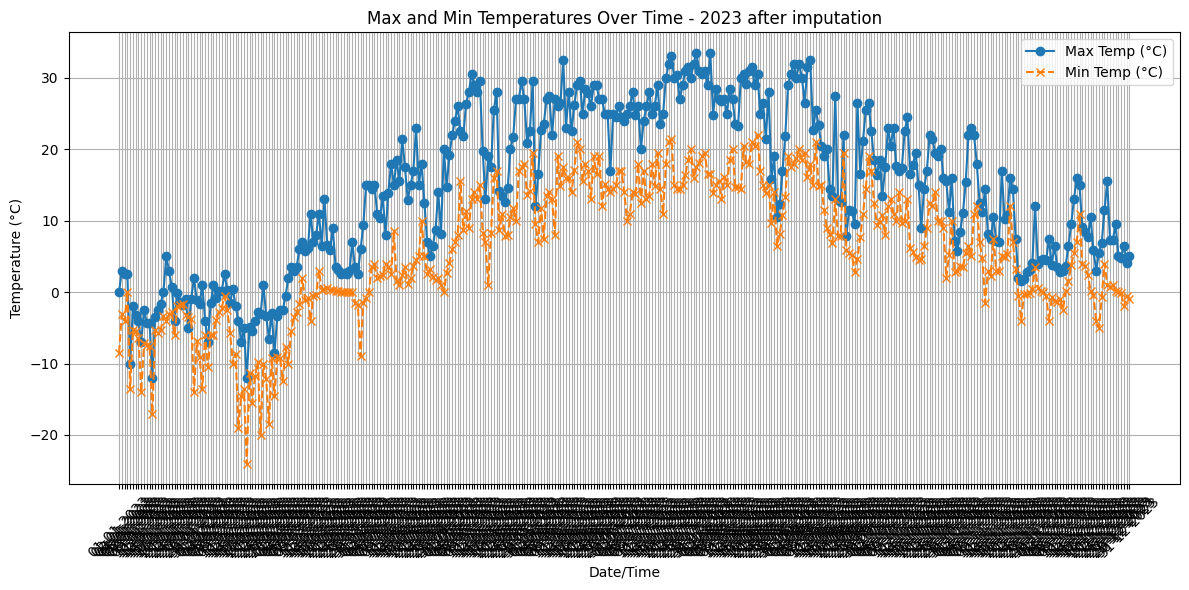

In [71]:
plt.figure(figsize=(12, 6))
plt.plot(Weather_Data_2023['Date/Time'], Weather_Data_2023['Max Temp (°C)'], label='Max Temp (°C)',marker='o', linestyle='-')
plt.plot(Weather_Data_2023['Date/Time'], Weather_Data_2023['Min Temp (°C)'], label='Min Temp (°C)',marker='x', linestyle='--')
plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.title('Max and Min Temperatures Over Time - 2023 after imputation')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

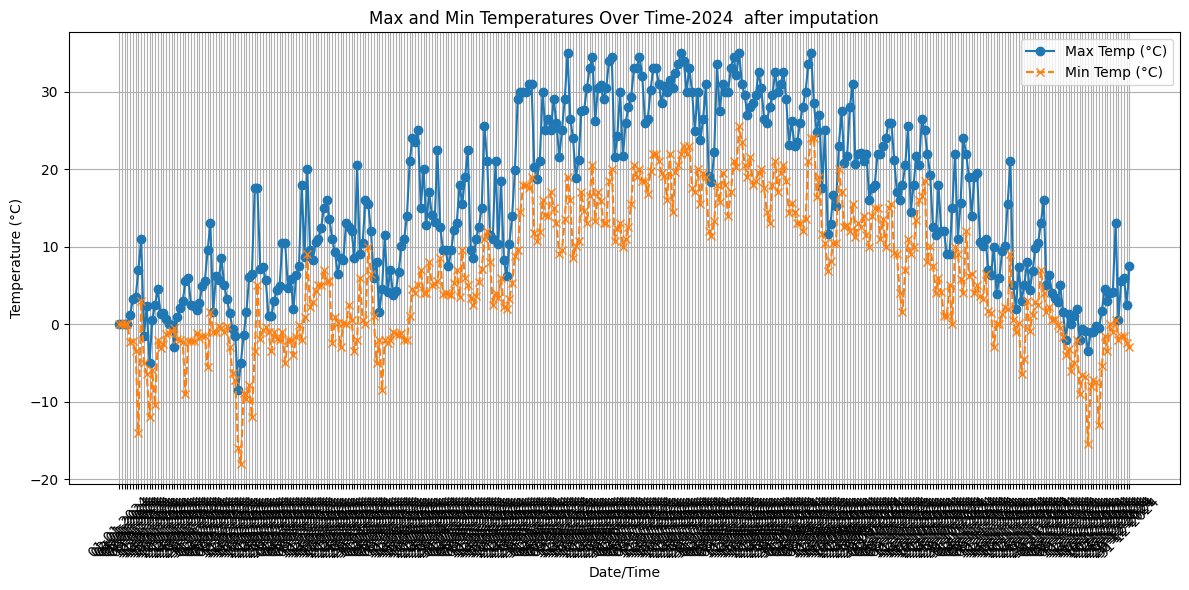

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(Weather_Data_2024['Date/Time'], Weather_Data_2024['Max Temp (°C)'], label='Max Temp (°C)',marker='o', linestyle='-')
plt.plot(Weather_Data_2024['Date/Time'], Weather_Data_2024['Min Temp (°C)'], label='Min Temp (°C)',marker='x', linestyle='--')
plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.title('Max and Min Temperatures Over Time-2024  after imputation')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

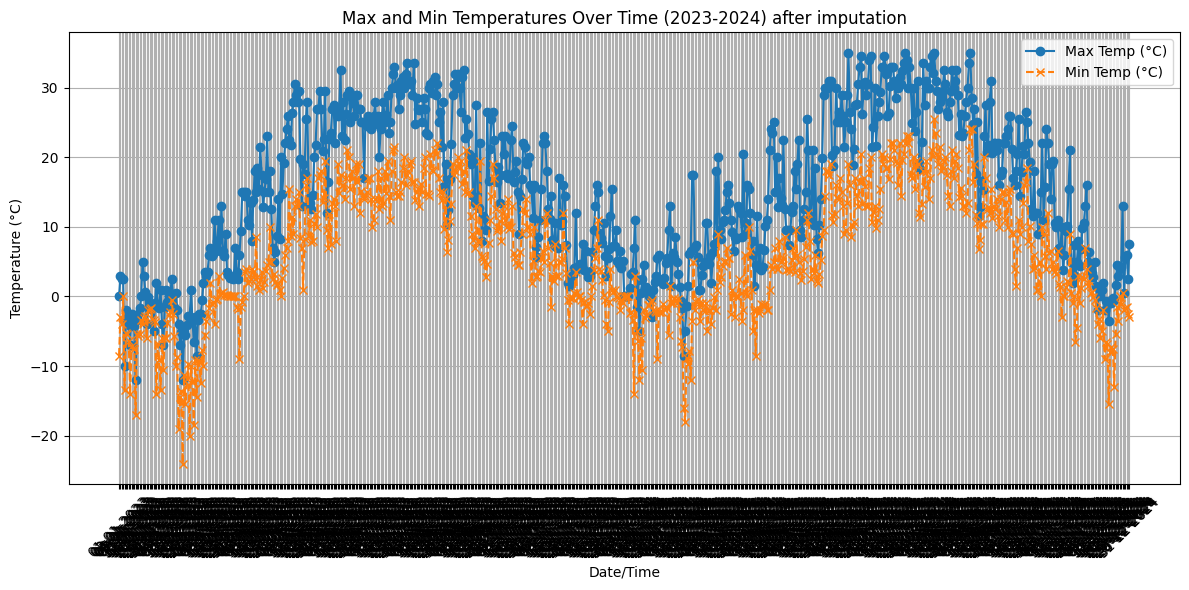

In [73]:
# Concatenate the two DataFrames
combined_weather_data_after_imputation = pd.concat([Weather_Data_2023, Weather_Data_2024], ignore_index=True)

# Display the first few rows of the combined dataset
combined_weather_data_after_imputation.head

plt.figure(figsize=(12, 6))
plt.plot(combined_weather_data_after_imputation['Date/Time'], combined_weather_data_after_imputation['Max Temp (°C)'], label='Max Temp (°C)', marker='o', linestyle='-')
plt.plot(combined_weather_data_after_imputation['Date/Time'], combined_weather_data_after_imputation['Min Temp (°C)'], label='Min Temp (°C)', marker='x', linestyle='--')
plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.title('Max and Min Temperatures Over Time (2023-2024) after imputation')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
df = pd.read_csv("preprocessed_data.csv")
df.shape

FileNotFoundError: [Errno 2] No such file or directory: 'preprocessed_data.csv'

In [ ]:
# Select the columns for correlation analysis
correlation_data = pd.concat([df['gmv'], combined_weather_data_after_imputation.drop(columns=['Date/Time','Data Quality'])], axis=1)

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: GMV vs. Combined Weather Data')
plt.show()

In [ ]:
combined_weather_data_after_imputation.to_csv('combined_weather_data_after_imputation.csv', index=False)
combined_weather_data_after_imputation = combined_weather_data_after_imputation.drop(columns=['Data Quality'], errors='ignore')
combined_weather_data_after_imputation.to_csv('combined_weather_data_after_imputation.csv', index=False)

## Budget Optimization

In [ ]:

# Load the Excel file
file_path = "Media data-Sale Calendar-NPS Scores_Data.xlsx"
xls = pd.ExcelFile(file_path)

# Display sheet names
xls.sheet_names


['Media Investment', 'Special Sale Calendar', 'Monthly NPS Score']

In [ ]:
media_df = pd.read_excel(xls, sheet_name="Media Investment")

In [ ]:
# Remove unnecessary rows and rename columns properly
media_df_cleaned = media_df.iloc[2:].reset_index(drop=True)

# Rename columns
media_df_cleaned.columns = [
    "Drop1", "Year", "Month", "Total Investment", "TV", "Digital", "Sponsorship",
    "Content Marketing", "Online Marketing", "Affiliates", "SEM", "Radio", "Other"
]

# Drop unnecessary first column
media_df_cleaned = media_df_cleaned.drop(columns=["Drop1"])

# Convert all relevant columns to numeric
cols_to_convert = [
    "Total Investment", "TV", "Digital", "Sponsorship", "Content Marketing",
    "Online Marketing", "Affiliates", "SEM", "Radio", "Other"
]

media_df_cleaned[cols_to_convert] = media_df_cleaned[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Multiply by 1 crore (10^7)
media_df_cleaned[cols_to_convert] *= 10**7

# Fill missing values in "Radio" and "Other" with 1
media_df_cleaned["Radio"].fillna(1, inplace=True)
media_df_cleaned["Other"].fillna(1, inplace=True)

C:\Users\ajsal\AppData\Local\Temp\ipykernel_7752\1836338085.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  media_df_cleaned["Radio"].fillna(1, inplace=True)
C:\Users\ajsal\AppData\Local\Temp\ipykernel_7752\1836338085.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [ ]:
# Create the GMV DataFrame
gmv_list = [
    174206832, 416096, 421760671, 502727831, 331386937,
    435820199, 387192999, 331567025, 404003023, 339703548,
    409453151, 305913306
]
gmv_df = pd.DataFrame({'GMV': gmv_list})

# Reset index of both DataFrames to ensure proper alignment
gmv_df.reset_index(drop=True, inplace=True)
media_df_cleaned.reset_index(drop=True, inplace=True)

# Concatenate the two DataFrames along columns
final_df = pd.concat([gmv_df, media_df_cleaned], axis=1)

In [ ]:

# Convert the scientific notation to full float values
pd.options.display.float_format = '{:.2f}'.format
final_df

In [ ]:
# # Prepare the input data (log-transform budgets)
X = np.log(final_df[['TV', 'Digital', 'Sponsorship', 'Content Marketing', 'Online Marketing','Affiliates','SEM','Radio','Other']])
y = final_df['GMV']

# # Fit regression model
# reg = LinearRegression()
# reg.fit(X, y)

# # Extract parameters
# k = reg.intercept_
# b_coefficients = reg.coef_

# print("Intercept (k):", k)
# for i, b in enumerate(b_coefficients, start=1):
#     print(f"Coefficient b{i}: {b}")
# y_pred = reg.predict(X)


# mse = mean_squared_error(y, y_pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y, y_pred)
# r2 = r2_score(y, y_pred)

# print(f"Mean Squared Error (MSE): {mse:.2f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
# print(f"Mean Absolute Error (MAE): {mae:.2f}")
# print(f"R-squared (R²): {r2:.4f}")

## Lasso Regression with Cross-Validation
Implemented Lasso Regression with α = 1.0 to introduce feature selection via L1 regularization.
Used cross-validation (cv=4) for robust model evaluation.
Computed MSE, RMSE, MAE, and R² to assess model performance.
Extracted intercept and coefficients to analyze feature importance.

In [ ]:
# from sklearn.linear_model import Lasso
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.model_selection import cross_val_predict

# # Initialize Lasso Regression model
# lasso_model = Lasso(alpha=1.0)

# # Perform cross-validation predictions
# y_pred_lasso = cross_val_predict(lasso_model, X, y, cv=4)

# # Calculate metrics
# lasso_mse = mean_squared_error(y, y_pred_lasso)
# lasso_rmse = np.sqrt(lasso_mse)
# lasso_mae = mean_absolute_error(y, y_pred_lasso)
# lasso_r2 = r2_score(y, y_pred_lasso)

# # Print results
# print("Lasso Regression Evaluation Metrics:")
# print(f"Mean Squared Error (MSE): {lasso_mse:.2f}")
# print(f"Root Mean Squared Error (RMSE): {lasso_rmse:.2f}")
# print(f"Mean Absolute Error (MAE): {lasso_mae:.2f}")
# print(f"R-squared (R²): {lasso_r2:.4f}")
# k = reg.intercept_
# b_coefficients = reg.coef_

# print("Intercept (k):", k)
# for i, b in enumerate(b_coefficients, start=1):
#     print(f"Coefficient b{i}: {b}")

In [ ]:
# from sklearn.linear_model import ElasticNet
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.model_selection import cross_val_predict

# # Initialize ElasticNet Regression model
# elasticnet_model = ElasticNet(alpha=0.1, l1_ratio=0.01)

# # Perform cross-validation predictions
# y_pred_elasticnet = cross_val_predict(elasticnet_model, X, y, cv=4)

# # Calculate metrics
# elasticnet_mse = mean_squared_error(y, y_pred_elasticnet)
# elasticnet_rmse = np.sqrt(elasticnet_mse)
# elasticnet_mae = mean_absolute_error(y, y_pred_elasticnet)
# elasticnet_r2 = r2_score(y, y_pred_elasticnet)

# # Print results
# print("ElasticNet Regression Evaluation Metrics:")
# print(f"Mean Squared Error (MSE): {elasticnet_mse:.2f}")
# print(f"Root Mean Squared Error (RMSE): {elasticnet_rmse:.2f}")
# print(f"Mean Absolute Error (MAE): {elasticnet_mae:.2f}")
# print(f"R-squared (R²): {elasticnet_r2:.4f}")
# k = reg.intercept_
# b_coefficients = reg.coef_

# print("Intercept (k):", k)
# for i, b in enumerate(b_coefficients, start=1):
#     print(f"Coefficient b{i}: {b}")


In [ ]:
# Prepare input features and target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Ridge regression model
ridge_model = Ridge()

# Define hyperparameter grid for alpha
param_grid = {'alpha': [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]}

# Set up GridSearchCV
grid_search = GridSearchCV(ridge_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=4)

# Fit the model on training data
grid_search.fit(X_train, y_train)

# Best alpha value
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Evaluate the optimized model on test data
optimized_ridge_model = grid_search.best_estimator_
y_pred = optimized_ridge_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nOptimized Ridge Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")
#The variable 'reg' was not defined. We need to use the defined and fitted 'optimized_ridge_model' instead.
k = optimized_ridge_model.intercept_
b_coefficients = optimized_ridge_model.coef_

print("Intercept (k):", k)
for i, b in enumerate(b_coefficients, start=1):
    print(f"Coefficient b{i}: {b}")

In [ ]:

# Prepare input features and target variable (Ensure X and y are defined)
# Create an empty list to store error sums for each random state
error_sums = []

# Iterate through random states from 1 to 300
for random_state in range(1, 301):
    # Split data into training and testing sets with the current random state
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Define Ridge regression model
    ridge_model = Ridge()

    # Define hyperparameter grid for alpha
    param_grid = {'alpha': [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]}

    # Set up GridSearchCV
    grid_search = GridSearchCV(ridge_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=4)

    # Fit the model on training data
    grid_search.fit(X_train, y_train)

    # Best alpha value
    best_alpha = grid_search.best_params_['alpha']
   # print(f"Best alpha: {best_alpha}")

    # Evaluate the optimized model on test data
    optimized_ridge_model = grid_search.best_estimator_
    y_pred = optimized_ridge_model.predict(X_test)

    # Calculate errors for the current random state and append the sum to the list
    errors = y_test - y_pred
    error_sums.append(np.sum(errors))

# Calculate the total sum of errors across all random states (outside the loop)
total_error_sum = np.sum(error_sums)

print(f"Total sum of errors across all random states: {total_error_sum:.2f}")

# # Model coefficients and intercept
# k = optimized_ridge_model.intercept_
# b_coefficients = optimized_ridge_model.coef_

# print("Intercept (k):", k)
# for i, b in enumerate(b_coefficients, start=1):
#     print(f"Coefficient b{i}: {b}")


In [ ]:


# Prepare input features and target variable (Ensure X and y are defined)
# Create an empty list to store error sums for each random state
error_sums = []

# Iterate through random states from 1 to 300
for random_state in range(1, 301):
    # Split data into training and testing sets with the current random state
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Define Ridge regression model with constant alpha = 0.01
    ridge_model = Ridge(alpha=0.01)

    # Fit the model on training data
    ridge_model.fit(X_train, y_train)

    # Evaluate the optimized model on test data
    y_pred = ridge_model.predict(X_test)

    # Calculate errors for the current random state and append the sum to the list
    errors = y_test - y_pred

    # The line below was incorrectly indented
    error_sums.append(np.sum(errors))

# Calculate the total sum of errors across all random states (outside the loop)
total_error_sum = np.sum(error_sums)

print(f"Total sum of errors across all random states: {total_error_sum:.2f}")

# Model coefficients and intercept
k = ridge_model.intercept_
b_coefficients = ridge_model.coef_

print("Intercept (k):", k)
for i, b in enumerate(b_coefficients, start=1):
    print(f"Coefficient b{i}: {b}")

In [ ]:
def optimal_budget_allocation(b_coefficients, total_budget):
    # Handle negative or zero coefficients by setting them to zero (no allocation)
    positive_b = np.maximum(b_coefficients, 0)

    if positive_b.sum() == 0:
        # If all coefficients are zero or negative, allocate evenly
        return np.full_like(positive_b, total_budget / len(positive_b))

    # Allocate proportionally based on positive coefficients
    optimal_allocations = positive_b / positive_b.sum() * total_budget
    return optimal_allocations


total_budget_next_month = 170617754.43
optimal_allocations = optimal_budget_allocation(b_coefficients, total_budget_next_month)

for idx, alloc in enumerate(optimal_allocations, start=1):
    print(f"Optimal budget for Channel {idx}: ₹{alloc:.2f}")


NameError: name 'b_coefficients' is not defined

## Budget opt Dharya ##

In [ ]:

# Number of assets
n = 9

# Coefficients for log(w) term
coefficients = np.array([
    48455469.40939132, -34398380.17599626, 39135513.63621925, 
    41416400.6860923, -583731166.315311, 532057168.5703044, 
    64632102.44577668, 98549981.72944725, -85375576.55458942
])
intercept = -855592288.9244535
budget = 1e9
epsilon = 1e-6  # Small constant to prevent log(0)

# Objective function
def objective(w):
    return np.sum(coefficients * np.log(np.maximum(w, epsilon))*budget) + intercept - budget * np.sum(w)

# Gradient of the objective function
def gradient(w):
    return (coefficients / np.maximum(w, epsilon)) - budget  # ∂f/∂w

# Gradient Ascent Parameters
alpha = 0.001  # Learning rate
max_iters = 10000  # Maximum iterations
tolerance = 1e-9  # Stop when gradient is small

# Initialize weights (equal distribution)
w = np.ones(n) / n

# Gradient Ascent Loop
for i in range(max_iters):
    grad = gradient(w)
    w_new = w + alpha * grad  # Gradient ascent update
    w_new = np.maximum(w_new, epsilon)  # Ensure no negative values
    w_new /= np.sum(w_new)  # Normalize to ensure sum(w) = 1
    
    # Check for convergence
    if np.linalg.norm(w_new - w) < tolerance:
        print(f"Converged in {i+1} iterations")
        break
    
    w = w_new

# Display results
print("Optimal portfolio weights:", w)
print(w*budget)
# print("Maximum profit:", objective(w))

In [ ]:
Maximum profit: 1360569684.0782197

In [ ]:
print(np.sum(w))

In [ ]:
import numpy as np
sum=0
x=w
temp=coefficients
for i in range(len(w)):
    if(x[i]<1e-9):
        temp[i]=0
    sum=sum+temp[i]*np.log(x[i]*budget)
print(sum+intercept-budget)
print(budget)

In [ ]:
max_val=0
roi=0
for i in range(4):
    budget=10**(i+7)
    su=0
    x=w
    temp=coefficients
    for j in range(len(w)):
        if(x[j]<1e-9):
            temp[j]=0
        su=su+temp[j]*np.log(x[j]*budget)
    su=su+intercept-budget
    temp1=su/budget
    if(temp1>roi):
        roi=temp1
        
print(roi)
